# Questão 1: Co-clustering da base *Spambase* com **Double K-means**

**Projeto de Aprendizagem de Máquina 2026-2** · Prof. Francisco de A. T. de Carvalho · CIn/UFPE

---

## Objetivo

Aplicar o algoritmo **Double K-means** (agrupamento simultâneo de objetos e variáveis,
*co-clustering*) à base **Spambase** e, a partir dos resultados:

1. Executar o algoritmo **100 vezes** para cada par $(K, H)$ com $K \in \{2,3,4\}$ e
   $H \in \{1, \dots, K\}$, retendo em cada par o melhor resultado segundo a função objetivo.
2. Calcular a **silhueta** de cada par, plotar $Sil \times (K,H)$ e escolher
   $K^* = \arg\max_{(K,H)} Sil(K,H)$.
3. Calcular o **índice de Rand corrigido** da partição de objetos com $K^*$ contra a
   partição *a priori* (spam / não-spam) e comentar.
4. Para o melhor resultado com $K^*$, apresentar: **(i)** a matriz de protótipos dos blocos
   $\mathbf{G}$; **(ii)** a matriz de confusão partição-do-algoritmo × partição *a priori*;
   **(iv)** o plot da função objetivo × iterações.

## Roteiro do notebook

| Seção | Conteúdo |
|---|---|
| 0 | Configuração do ambiente |
| 1 | Descrição e **análise exploratória** dos dados |
| 2 | Pré-processamento: padronização e sua justificativa |
| 3 | Double K-means: formulação, implementação e **validação da implementação** |
| 4 | Protocolo experimental e sensibilidade à inicialização |
| 5 | Escolha de $K^*$ pela silhueta |
| 6 | Índice de Rand corrigido |
| 7 | Resultados detalhados para $(K^*, H^*)$, incluindo a matriz de dados reorganizada |
| 8 | **Análise crítica dos resultados**, estudo de sensibilidade e ponte para a Questão 2 |
| 9 | Conclusões |


---
## 0. Configuração do ambiente

Bibliotecas, semente global de reprodutibilidade e padrões visuais dos gráficos.
Todo o notebook é **determinístico**: as sementes são fixadas por par $(K,H)$ e por execução,
de modo que reexecutá-lo reproduz exatamente os mesmos números.


In [1]:
import json
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# --- Reprodutibilidade -------------------------------------------------------
MASTER_SEED = 42
N_INIT = 100        # execucoes por par (K, H), conforme o enunciado
MAX_ITER = 100      # limite de seguranca por execucao
K_VALUES = (2, 3, 4)

np.random.seed(MASTER_SEED)

# --- Apresentacao ------------------------------------------------------------
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

mpl.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.titleweight": "600",
    "font.size": 9.5,
    "legend.frameon": False,
})

# Paleta usada de forma consistente em todo o notebook
C_PRIMARY   = "#33538f"   # azul, grandezas principais
C_SECONDARY = "#c2703d"   # terracota, contraste / K=3
C_TERTIARY  = "#4e8a6b"   # verde, K=4
C_MUTED     = "#9a958a"   # neutro
C_ALERT     = "#a8433a"   # destaque crítico
K_COLORS    = {2: C_PRIMARY, 3: C_SECONDARY, 4: C_TERTIARY}

print("Ambiente configurado.")
print(f"numpy {np.__version__} | pandas {pd.__version__}")


Ambiente configurado.
numpy 2.5.2 | pandas 3.0.5


In [2]:
# Localiza a base (o notebook pode ser executado a partir de q1/ ou da raiz do projeto)
def find_data_dir() -> Path:
    for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
        if (candidate / "spambase.data").exists():
            return candidate
    raise FileNotFoundError("spambase.data nao encontrado a partir de " + str(Path.cwd()))

DATA_DIR = find_data_dir()
RESULTS_DIR = Path.cwd() / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print("Dados em :", DATA_DIR)
print("Saidas em:", RESULTS_DIR)


Dados em : /Users/yarafaran/Documents/AM
Saidas em: /Users/yarafaran/Documents/AM/q1/results


---
# 1. Descrição e análise exploratória dos dados

## 1.1 Origem e estrutura

A base **Spambase** ([UCI ML Repository, dataset 94](https://archive.ics.uci.edu/dataset/94/spambase))
foi construída a partir de caixas de e-mail reais: as mensagens de *spam* vieram de reclamações
de usuários e de armadilhas de coleta; as mensagens legítimas (*ham*) vieram de e-mails
corporativos e pessoais de um funcionário da **HP Labs**, detalhe que será decisivo na
análise dos resultados (Seção 8).

Cada e-mail é descrito por **57 variáveis contínuas**, organizadas em três famílias:

| Família | Nº | Descrição | Faixa |
|---|---|---|---|
| `word_freq_*` | 48 | % de palavras do e-mail que coincidem com uma palavra-alvo | 0–100 |
| `char_freq_*` | 6 | % de caracteres do e-mail que coincidem com um caractere-alvo | 0–100 |
| `capital_run_length_*` | 3 | comprimento médio / máximo / total das sequências ininterruptas de maiúsculas | 1–∞ |

Há ainda o rótulo **a priori** `spam ∈ {0,1}`. Ele **não é usado no agrupamento**, o
Double K-means é não supervisionado. O rótulo entra apenas *depois*, como validação
externa (índice de Rand corrigido e matriz de confusão).


In [3]:
ATTRIBUTE_NAMES = [
    "word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d",
    "word_freq_our", "word_freq_over", "word_freq_remove", "word_freq_internet",
    "word_freq_order", "word_freq_mail", "word_freq_receive", "word_freq_will",
    "word_freq_people", "word_freq_report", "word_freq_addresses", "word_freq_free",
    "word_freq_business", "word_freq_email", "word_freq_you", "word_freq_credit",
    "word_freq_your", "word_freq_font", "word_freq_000", "word_freq_money",
    "word_freq_hp", "word_freq_hpl", "word_freq_george", "word_freq_650",
    "word_freq_lab", "word_freq_labs", "word_freq_telnet", "word_freq_857",
    "word_freq_data", "word_freq_415", "word_freq_85", "word_freq_technology",
    "word_freq_1999", "word_freq_parts", "word_freq_pm", "word_freq_direct",
    "word_freq_cs", "word_freq_meeting", "word_freq_original", "word_freq_project",
    "word_freq_re", "word_freq_edu", "word_freq_table", "word_freq_conference",
    "char_freq_;", "char_freq_(", "char_freq_[", "char_freq_!", "char_freq_$",
    "char_freq_#", "capital_run_length_average", "capital_run_length_longest",
    "capital_run_length_total",
]

df = pd.read_csv(DATA_DIR / "spambase.data", header=None,
                 names=ATTRIBUTE_NAMES + ["spam"])

X_raw = df[ATTRIBUTE_NAMES].to_numpy(dtype=np.float64)
y = df["spam"].to_numpy(dtype=np.int64)
N, P = X_raw.shape

print(f"N (objetos)   = {N}")
print(f"P (variaveis) = {P}")
print(f"Valores ausentes: {int(df.isna().sum().sum())}")
print(f"Linhas duplicadas: {int(df.duplicated().sum())}")
df.head()


N (objetos)   = 4601
P (variaveis) = 57
Valores ausentes: 0
Linhas duplicadas: 391


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [4]:
# Familias de variaveis (usadas em varias analises adiante)
FAMILY = pd.Series(
    np.where(pd.Index(ATTRIBUTE_NAMES).str.startswith("word_freq"), "word_freq",
    np.where(pd.Index(ATTRIBUTE_NAMES).str.startswith("char_freq"), "char_freq",
             "capital_run")),
    index=ATTRIBUTE_NAMES, name="familia")

FAMILY.value_counts().rename("n_variaveis").to_frame()


,n_variaveis
familia,
word_freq,48
char_freq,6
capital_run,3


## 1.2 Distribuição das classes *a priori*

A base é moderadamente desbalanceada, mas sem desbalanceamento severo, o que é relevante
porque um agrupamento em $K=2$ grupos *poderia*, em princípio, recuperar essa estrutura.


findfont: Failed to find font weight 600, now using 700.


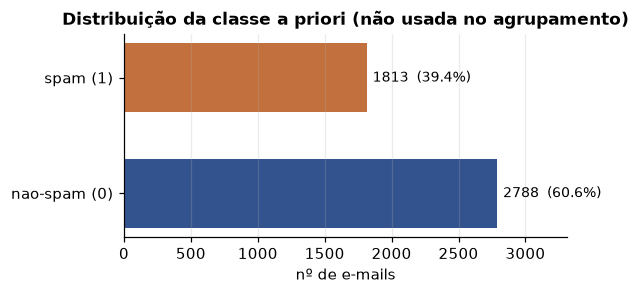

,n_emails,proporcao
nao-spam (0),2788,0.606
spam (1),1813,0.394


In [5]:
counts = pd.Series(y).value_counts().sort_index()
counts.index = ["nao-spam (0)", "spam (1)"]
resumo_classes = pd.DataFrame({
    "n_emails": counts,
    "proporcao": (counts / N).round(4),
})

fig, ax = plt.subplots(figsize=(5.2, 2.4))
bars = ax.barh(resumo_classes.index, resumo_classes["n_emails"],
               color=[C_PRIMARY, C_SECONDARY], height=0.6)
for bar, (n, prop) in zip(bars, resumo_classes[["n_emails", "proporcao"]].to_numpy()):
    ax.text(bar.get_width() + 45, bar.get_y() + bar.get_height() / 2,
            f"{int(n)}  ({prop:.1%})", va="center", fontsize=9)
ax.set_xlim(0, N * 0.72)
ax.set_xlabel("nº de e-mails")
ax.set_title("Distribuição da classe a priori (não usada no agrupamento)")
ax.grid(axis="y", visible=False)
plt.show()

resumo_classes


## 1.3 Escalas heterogêneas

Este é o primeiro fato estruturante da base. O Double K-means minimiza uma soma de
**distâncias euclidianas ao quadrado**; portanto, variáveis com variância muito maior
dominam a função objetivo e, na prática, decidem sozinhas a partição.

Vejamos a ordem de grandeza de cada família.


In [6]:
desc = pd.DataFrame({
    "familia": FAMILY,
    "min": X_raw.min(axis=0),
    "mediana": np.median(X_raw, axis=0),
    "media": X_raw.mean(axis=0),
    "max": X_raw.max(axis=0),
    "desvio_padrao": X_raw.std(axis=0, ddof=1),
    "variancia": X_raw.var(axis=0, ddof=1),
}, index=ATTRIBUTE_NAMES)

resumo_familia = desc.groupby("familia").agg(
    n=("max", "size"),
    max_observado=("max", "max"),
    desvio_padrao_mediano=("desvio_padrao", "median"),
    variancia_total=("variancia", "sum"),
)
resumo_familia["% da variancia total"] = (
    100 * resumo_familia["variancia_total"] / desc["variancia"].sum()
)
resumo_familia.round(2)


,n,max_observado,desvio_padrao_mediano,variancia_total,% da variancia total
familia,,,,,
capital_run,3,15841.00,194.89,406647.10,99.99
char_freq,6,32.48,0.26,1.05,0.00
word_freq,48,42.81,0.45,34.27,0.01


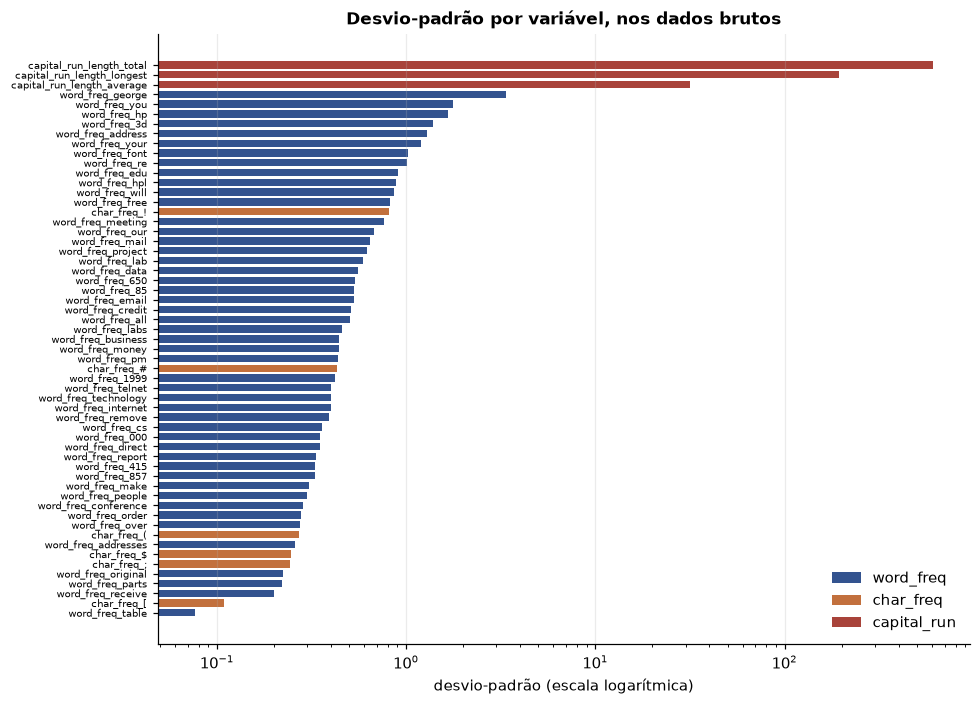

In [7]:
ordem = desc["desvio_padrao"].sort_values(ascending=False)
cores = [ {"word_freq": C_PRIMARY, "char_freq": C_SECONDARY,
           "capital_run": C_ALERT}[FAMILY[v]] for v in ordem.index ]

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(range(len(ordem)), ordem.to_numpy(), color=cores, height=0.75)
ax.set_yticks(range(len(ordem)))
ax.set_yticklabels(ordem.index, fontsize=6.5)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("desvio-padrão (escala logarítmica)")
ax.set_title("Desvio-padrão por variável, nos dados brutos")
ax.legend(handles=[Patch(facecolor=C_PRIMARY, label="word_freq"),
                   Patch(facecolor=C_SECONDARY, label="char_freq"),
                   Patch(facecolor=C_ALERT, label="capital_run")],
          loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()


> **Leitura.** As três variáveis `capital_run_length_*` respondem por praticamente toda a
> variância da base bruta, `capital_run_length_total` sozinha tem desvio-padrão da ordem de
> centenas, contra frações de unidade das `word_freq_*`. **Sem padronização, o Double K-means
> agruparia os e-mails essencialmente por "quantidade de letras maiúsculas"**, ignorando as
> 54 demais variáveis. Isso motiva a decisão da Seção 2.


## 1.4 Assimetria e esparsidade

A segunda característica estruturante: as variáveis de frequência de palavras são
**altamente esparsas** (muitos zeros) e **fortemente assimétricas à direita**. Isso importa
porque, após a padronização, uma variável quase sempre nula transforma os seus poucos valores
não nulos em *escores z* extremos, combustível para clusters formados por outliers.


In [8]:
diag = pd.DataFrame({
    "familia": FAMILY,
    "frac_zeros": (X_raw == 0).mean(axis=0),
    "assimetria": pd.DataFrame(X_raw, columns=ATTRIBUTE_NAMES).skew().to_numpy(),
    "curtose": pd.DataFrame(X_raw, columns=ATTRIBUTE_NAMES).kurtosis().to_numpy(),
}, index=ATTRIBUTE_NAMES)

print(f"Fracao global de zeros na matriz de dados: {(X_raw == 0).mean():.1%}")
print(f"Variaveis com >80% de zeros: {(diag['frac_zeros'] > 0.80).sum()} de {P}")
print(f"Assimetria mediana (word_freq): {diag.loc[FAMILY == 'word_freq', 'assimetria'].median():.1f}")

diag.sort_values("frac_zeros", ascending=False).head(12).round(3)


Fracao global de zeros na matriz de dados: 77.4%
Variaveis com >80% de zeros: 38 de 57
Assimetria mediana (word_freq): 8.8


,familia,frac_zeros,assimetria,curtose
word_freq_3d,word_freq,0.990,26.228,726.452
word_freq_table,word_freq,0.986,19.868,459.433
word_freq_parts,word_freq,0.982,28.263,912.046
word_freq_font,word_freq,0.975,9.975,109.142
word_freq_cs,word_freq,0.968,12.588,193.619
word_freq_conference,word_freq,0.956,19.720,537.493
word_freq_857,word_freq,0.955,10.549,127.377
word_freq_415,word_freq,0.953,10.475,125.943
word_freq_telnet,word_freq,0.936,12.669,254.233
word_freq_project,word_freq,0.929,18.772,479.831


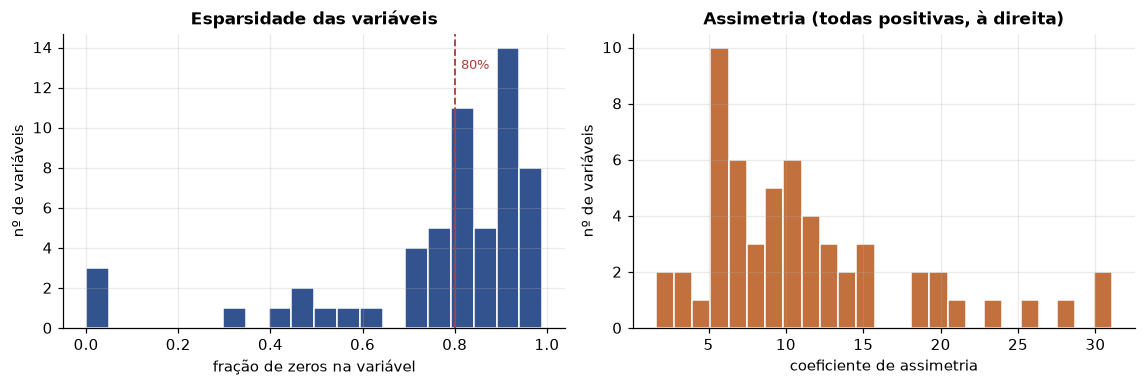

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))

axes[0].hist(diag["frac_zeros"], bins=20, color=C_PRIMARY, edgecolor="white")
axes[0].axvline(0.80, color=C_ALERT, linestyle="--", linewidth=1.2)
axes[0].text(0.805, axes[0].get_ylim()[1] * 0.88, " 80%", color=C_ALERT, fontsize=8.5)
axes[0].set_xlabel("fração de zeros na variável")
axes[0].set_ylabel("nº de variáveis")
axes[0].set_title("Esparsidade das variáveis")

axes[1].hist(diag["assimetria"], bins=25, color=C_SECONDARY, edgecolor="white")
axes[1].set_xlabel("coeficiente de assimetria")
axes[1].set_ylabel("nº de variáveis")
axes[1].set_title("Assimetria (todas positivas, à direita)")

plt.tight_layout()
plt.show()


## 1.5 Valores discrepantes (*outliers*)

O material de apoio lista explicitamente entre as desvantagens do Double K-means que ele
**"é sensível a valores discrepantes"**. Vale então quantificar quantos há.

Contamos, para os dados já padronizados, quantas observações excedem $|z| > 10$, um limiar
bastante conservador (sob normalidade, esperaríamos ~0 em 4601 observações).


In [10]:
Z_probe = StandardScaler().fit_transform(X_raw)

outliers = pd.DataFrame({
    "familia": FAMILY,
    "max_|z|": np.abs(Z_probe).max(axis=0),
    "n_obs_|z|>10": (np.abs(Z_probe) > 10).sum(axis=0),
}, index=ATTRIBUTE_NAMES)

total_extremos = int((np.abs(Z_probe) > 10).any(axis=1).sum())
print(f"E-mails com pelo menos uma variavel |z| > 10: {total_extremos} ({total_extremos/N:.1%})")
print(f"Maior escore z observado na base: {np.abs(Z_probe).max():.1f}")

outliers.sort_values("max_|z|", ascending=False).head(12).round(2)


E-mails com pelo menos uma variavel |z| > 10: 302 (6.6%)
Maior escore z observado na base: 51.0


,familia,max_|z|,n_obs_|z|>10
capital_run_length_longest,capital_run,50.99,3
char_freq_#,char_freq,46.09,5
char_freq_!,char_freq,39.49,3
word_freq_parts,word_freq,37.70,6
word_freq_85,word_freq,37.38,2
char_freq_[,char_freq,37.15,8
char_freq_(,char_freq,35.56,4
word_freq_credit,word_freq,35.50,8
word_freq_conference,word_freq,34.89,7
capital_run_length_average,capital_run,34.59,9


> **Leitura.** 302 e-mails (6,6% da base) contêm ao menos um valor com $|z| > 10$, e o maior
> escore $z$ observado chega a **51 desvios-padrão**, algo impensável sob normalidade. Uma
> partição que isole um punhado desses pontos será geometricamente muito "limpa" e, como
> veremos, é exatamente isso que a silhueta vai premiar.


## 1.6 Estrutura de correlação entre as variáveis

O Double K-means agrupa também as **variáveis**. Faz sentido, portanto, verificar se existe
estrutura de co-ocorrência que justifique buscar $H > 1$ grupos de variáveis.


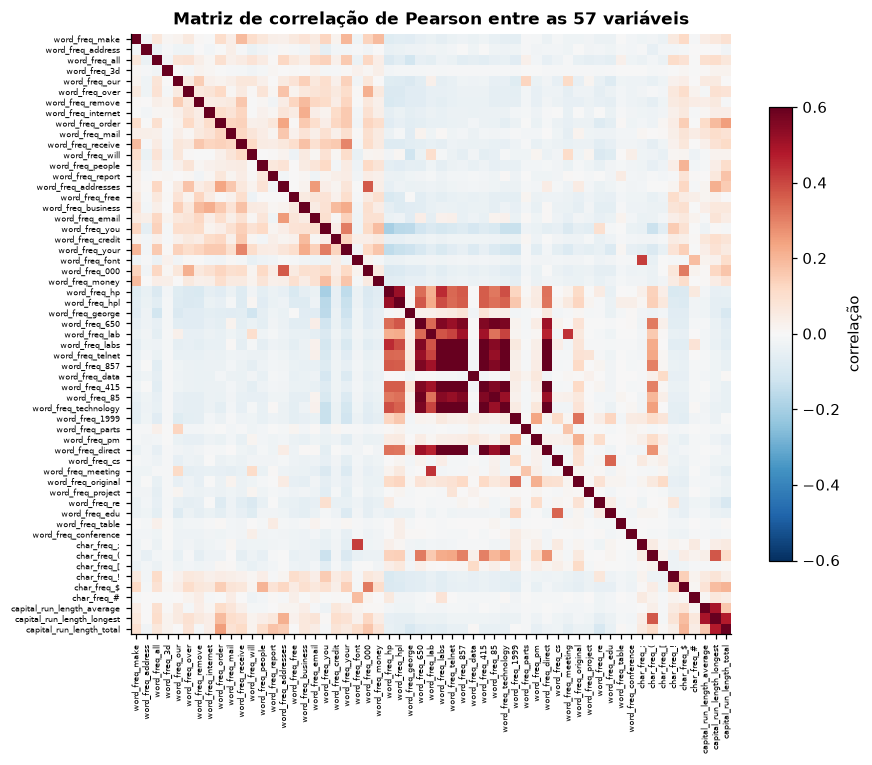

In [11]:
corr = pd.DataFrame(X_raw, columns=ATTRIBUTE_NAMES).corr()

fig, ax = plt.subplots(figsize=(8.2, 7))
im = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-0.6, vmax=0.6)
ax.set_xticks(range(P)); ax.set_xticklabels(ATTRIBUTE_NAMES, rotation=90, fontsize=5)
ax.set_yticks(range(P)); ax.set_yticklabels(ATTRIBUTE_NAMES, fontsize=5)
ax.set_title("Matriz de correlação de Pearson entre as 57 variáveis")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.72, label="correlação")
plt.tight_layout()
plt.show()


In [12]:
# Pares mais correlacionados (triangulo superior, sem a diagonal)
tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pares = (tri.sort_values(ascending=False).head(12)
               .rename("correlacao").reset_index()
               .rename(columns={"level_0": "variavel_A", "level_1": "variavel_B"}))
top_pares.round(3)


,variavel_A,variavel_B,correlacao
0,word_freq_857,word_freq_415,0.996
1,word_freq_857,word_freq_direct,0.848
2,word_freq_415,word_freq_direct,0.845
3,word_freq_telnet,word_freq_857,0.738
4,word_freq_telnet,word_freq_415,0.735
5,word_freq_857,word_freq_technology,0.730
6,word_freq_415,word_freq_technology,0.727
7,word_freq_telnet,word_freq_direct,0.700
8,word_freq_telnet,word_freq_technology,0.678
9,word_freq_technology,word_freq_direct,0.674


> **Leitura.** Emerge um bloco nítido de variáveis mutuamente correlacionadas,
> `857`, `415`, `direct`, `telnet`, `technology`, `labs`, `hp`, `hpl`, `george`, `650`, `85`,
> com correlações que vão de 0,66 até **0,996** (entre `word_freq_857` e `word_freq_415`).
> Note que são justamente os termos ligados ao **contexto corporativo do doador da base**
> (HP Labs, códigos de área da Califórnia, o nome próprio "george"). Fora desse bloco, as
> correlações da base são baixas. O co-clustering deverá isolar esse conjunto no eixo das
> variáveis; a questão em aberto é o que ele fará no eixo dos objetos.


## 1.7 Visão em duas dimensões (PCA)

Uma projeção nos dois primeiros componentes principais dá uma intuição sobre a geometria do
problema: existe separação visual entre spam e não-spam? Existem grupos compactos?


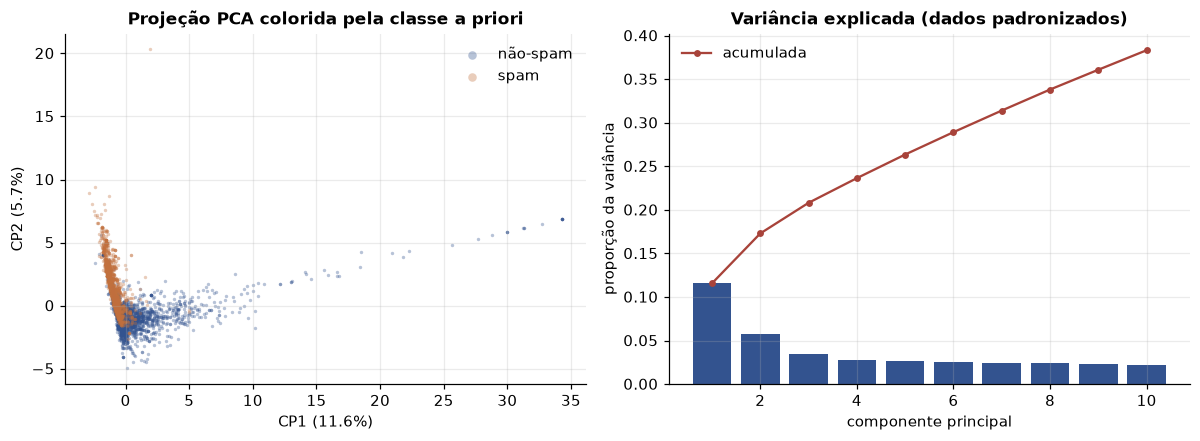

Variancia explicada pelos 2 primeiros CPs: 17.3%
Variancia explicada pelos 10 primeiros CPs: 38.3%


In [13]:
Z_probe_pca = PCA(n_components=10, random_state=MASTER_SEED).fit(Z_probe)
coords = Z_probe_pca.transform(Z_probe)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))

for classe, cor, rot in [(0, C_PRIMARY, "não-spam"), (1, C_SECONDARY, "spam")]:
    m = y == classe
    axes[0].scatter(coords[m, 0], coords[m, 1], s=5, alpha=0.35, color=cor, label=rot,
                    linewidths=0)
axes[0].set_xlabel(f"CP1 ({Z_probe_pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"CP2 ({Z_probe_pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("Projeção PCA colorida pela classe a priori")
axes[0].legend(markerscale=2.5)

ev = Z_probe_pca.explained_variance_ratio_
axes[1].bar(range(1, 11), ev, color=C_PRIMARY)
axes[1].plot(range(1, 11), np.cumsum(ev), color=C_ALERT, marker="o", markersize=3.5,
             label="acumulada")
axes[1].set_xlabel("componente principal")
axes[1].set_ylabel("proporção da variância")
axes[1].set_title("Variância explicada (dados padronizados)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Variancia explicada pelos 2 primeiros CPs: {ev[:2].sum():.1%}")
print(f"Variancia explicada pelos 10 primeiros CPs: {ev.sum():.1%}")


> **Leitura.** As classes spam e não-spam **se sobrepõem fortemente** no plano principal, e
> os dois primeiros componentes explicam pouco da variância total, a informação está
> espalhada em muitas direções. Não há indício visual de dois grupos compactos e separados
> que coincidam com o rótulo. O que se destaca, ao contrário, são alguns pontos muito
> afastados da nuvem principal: os outliers da Seção 1.5.


## 1.8 Síntese da análise exploratória

| Achado | Consequência metodológica |
|---|---|
| Escalas muito heterogêneas (`capital_run_*` domina a variância) | **Padronizar** as variáveis antes de agrupar (Seção 2) |
| 77% de zeros na matriz; 38 das 57 variáveis com >80% de zeros | Após padronização, valores raros viram escores $z$ extremos |
| 6,6% dos e-mails com algum $\|z\| > 10$; máximo de 51$\sigma$ | Risco real de clusters formados por outliers, o algoritmo é sensível a eles |
| Bloco de variáveis fortemente correlacionadas (`857`–`415`: 0,996) | Justifica buscar $H > 1$; provável grupo de variáveis a ser isolado |
| Classes sobrepostas na projeção PCA | **Não se deve esperar** que um método não supervisionado recupere o rótulo spam |

O último ponto é uma **hipótese formulada antes de rodar o algoritmo**, e será confrontada
com o índice de Rand corrigido na Seção 6.


---
# 2. Pré-processamento: padronização

Com base na Seção 1.3, todas as 57 variáveis são padronizadas por **escore $z$**:

$$ z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j} $$

de modo que cada variável passe a contribuir com a mesma variância ($=1$) para a função
objetivo. Sem isso, a partição seria decidida pelas três variáveis `capital_run_length_*`.

Esta é uma **decisão metodológica nossa**, o enunciado não a impõe. Ela é padrão para
métodos baseados em distância euclidiana, mas tem um efeito colateral que será
explicitamente auditado na Seção 8: ela amplifica os valores raros de variáveis esparsas.


In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

verificacao = pd.DataFrame({
    "media": X.mean(axis=0),
    "desvio_padrao": X.std(axis=0, ddof=0),
}, index=ATTRIBUTE_NAMES)

print("Apos a padronizacao:")
print(f"  media, min {verificacao['media'].min():+.2e} | max {verificacao['media'].max():+.2e}")
print(f"  desvio, min {verificacao['desvio_padrao'].min():.6f} | max {verificacao['desvio_padrao'].max():.6f}")
print(f"  matriz X: {X.shape[0]} x {X.shape[1]}")


Apos a padronizacao:
  media, min -7.41e-17 | max +8.65e-17
  desvio, min 1.000000 | max 1.000000
  matriz X: 4601 x 57


---
# 3. Double K-means: formulação e implementação

## 3.1 Formulação

Sejam $\mathbf{X} = (x_{ij})_{N \times P}$ a matriz de dados, $K$ o número de grupos de
objetos e $H$ o número de grupos de variáveis. O algoritmo busca simultaneamente:

- $\mathbf{U} = (u_{ik})_{N \times K}$, com $u_{ik} \in \{0,1\}$ e $\sum_k u_{ik} = 1$, partição dos **objetos**;
- $\mathbf{V} = (v_{jh})_{P \times H}$, com $v_{jh} \in \{0,1\}$ e $\sum_h v_{jh} = 1$, partição das **variáveis**;
- $\mathbf{G} = (g_{kh})_{K \times H}$, os **protótipos** dos $K \times H$ blocos;

minimizando a heterogeneidade total

$$ W(\mathbf{G}, \mathbf{U}, \mathbf{V}) = \sum_{k=1}^{K}\sum_{h=1}^{H}\sum_{i=1}^{N}\sum_{j=1}^{P} u_{ik}\, v_{jh}\, (x_{ij} - g_{kh})^2 . $$

A otimização é feita por **mínimos alternados**, repetindo três passos até que não haja mais
transferências de objetos nem de variáveis entre os grupos:

**Passo 1: protótipos** ($\mathbf{U}, \mathbf{V}$ fixos). Anulando $\partial W/\partial g_{kh}$:

$$ g_{kh} = \frac{\sum_{i}\sum_{j} u_{ik} v_{jh} x_{ij}}{n_k\, n_h} $$

**Passo 2: partição dos objetos** ($\mathbf{G}, \mathbf{V}$ fixos):

$$ u_{ik} = 1 \iff \sum_{h}\sum_{j} v_{jh}(x_{ij}-g_{kh})^2 = \min_{r=1..K} \sum_{h}\sum_{j} v_{jh}(x_{ij}-g_{rh})^2 $$

**Passo 3: partição das variáveis** ($\mathbf{G}, \mathbf{U}$ fixos):

$$ v_{jh} = 1 \iff \sum_{k}\sum_{i} u_{ik}(x_{ij}-g_{kh})^2 = \min_{s=1..H} \sum_{k}\sum_{i} u_{ik}(x_{ij}-g_{ks})^2 $$

Cada passo minimiza exatamente um bloco de parâmetros mantendo os demais fixos, logo
$W$ é **monotonicamente não crescente** ao longo das iterações e a convergência para um
**mínimo local** é garantida. Como o mínimo alcançado depende da solução inicial, o
algoritmo é executado várias vezes e retém-se a solução de menor $W$.

## 3.2 Implementação

A implementação abaixo é inteiramente **vetorizada em NumPy**: os passos 2 e 3 usam a
identidade $\|a-b\|^2 = \|a\|^2 - 2a^\top b + \|b\|^2$ para computar todas as distâncias
objeto×grupo (ou variável×grupo) em um único produto matricial. Isso torna viável executar
as 900 rodadas exigidas pelo enunciado em cerca de um minuto.


In [15]:
def _init_labels(n: int, n_clusters: int, rng: np.random.Generator) -> np.ndarray:
    # Particao inicial aleatoria garantindo que nenhum grupo nasca vazio.
    labels = np.empty(n, dtype=np.int64)
    order = rng.permutation(n)
    labels[order[:n_clusters]] = np.arange(n_clusters)
    if n > n_clusters:
        labels[order[n_clusters:]] = rng.integers(0, n_clusters, size=n - n_clusters)
    return labels


def _prototypes(X, u, v, K, H, prev_G=None):
    # PASSO 1: g_kh = soma dos x_ij no bloco kh / (n_k * n_h)
    U = np.eye(K, dtype=X.dtype)[u]          # N x K (matriz indicadora)
    V = np.eye(H, dtype=X.dtype)[v]          # P x H (matriz indicadora)
    block_sum = U.T @ X @ V                   # K x H, soma de cada bloco
    nk, nh = U.sum(axis=0), V.sum(axis=0)

    G = block_sum / np.outer(np.where(nk == 0, 1.0, nk), np.where(nh == 0, 1.0, nh))

    # Blocos cujo grupo ficou vazio nao tem media definida: preserva-se o
    # prototipo anterior para nao colapsar o grupo em zero.
    if prev_G is not None:
        if (nk == 0).any():
            G[nk == 0, :] = prev_G[nk == 0, :]
        if (nh == 0).any():
            G[:, nh == 0] = prev_G[:, nh == 0]
    return G, nk, nh


def _assign_objects(X, G, v):
    # PASSO 2: reatribui cada objeto ao grupo k mais proximo (G, V fixos)
    Ghat = G[:, v]                                        # K x P
    dist = (np.sum(X ** 2, axis=1, keepdims=True)
            - 2.0 * X @ Ghat.T
            + np.sum(Ghat ** 2, axis=1, keepdims=True).T)  # N x K
    return np.argmin(dist, axis=1)


def _assign_variables(X, G, u):
    # PASSO 3: reatribui cada variavel ao grupo h mais proximo (G, U fixos)
    Ghat = G[u, :]                                        # N x H
    dist = (np.sum(X ** 2, axis=0, keepdims=True).T
            - 2.0 * X.T @ Ghat
            + np.sum(Ghat ** 2, axis=0, keepdims=True))    # P x H
    return np.argmin(dist, axis=1)


def _objective(X, G, u, v) -> float:
    # W(G, U, V): soma dos quadrados dos residuos objeto-variavel-bloco
    return float(np.sum((X - G[u][:, v]) ** 2))


In [16]:
@dataclass
class DoubleKMeansResult:
    K: int
    H: int
    G: np.ndarray                    # K x H, matriz de prototipos
    u: np.ndarray                    # N, rotulos dos objetos
    v: np.ndarray                    # P, rotulos das variaveis
    objective: float                 # W final
    objective_history: list = field(default_factory=list)
    n_iter: int = 0
    converged: bool = False
    random_state: int = None


class DoubleKMeans:
    # Double K-means para dados vetoriais (co-clustering exclusivo).

    def __init__(self, n_row_clusters, n_col_clusters, max_iter=MAX_ITER, random_state=None):
        self.K = n_row_clusters
        self.H = n_col_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X) -> DoubleKMeansResult:
        X = np.asarray(X, dtype=np.float64)
        N, P = X.shape
        K, H = self.K, self.H
        rng = np.random.default_rng(self.random_state)

        # --- Inicializacao: (G0, U0, V0)
        u = _init_labels(N, K, rng)
        v = _init_labels(P, H, rng)
        G, _, _ = _prototypes(X, u, v, K, H)
        history = [_objective(X, G, u, v)]

        converged, it = False, 0
        for it in range(1, self.max_iter + 1):
            G, _, _ = _prototypes(X, u, v, K, H, prev_G=G)   # Passo 1
            u_new = _assign_objects(X, G, v)                  # Passo 2
            v_new = _assign_variables(X, G, u_new)             # Passo 3

            history.append(_objective(X, G, u_new, v_new))
            sem_transferencia = np.array_equal(u_new, u) and np.array_equal(v_new, v)
            u, v = u_new, v_new
            if sem_transferencia:                              # criterio de parada
                converged = True
                break

        G, _, _ = _prototypes(X, u, v, K, H, prev_G=G)
        final = _objective(X, G, u, v)
        history.append(final)

        return DoubleKMeansResult(K=K, H=H, G=G, u=u, v=v, objective=final,
                                  objective_history=history, n_iter=it,
                                  converged=converged, random_state=self.random_state)


def run_many(X, K, H, n_init=N_INIT, seed=0):
    # Executa n_init vezes com inicializacoes distintas e devolve
    # (melhor resultado segundo W, vetor com o W de cada execucao).
    melhor, todos_W = None, []
    for i in range(n_init):
        res = DoubleKMeans(K, H, random_state=seed + i).fit(X)
        todos_W.append(res.objective)
        if melhor is None or res.objective < melhor.objective:
            melhor = res
    return melhor, np.array(todos_W)

print("Double K-means implementado.")


Double K-means implementado.


## 3.3 Validação da implementação

Antes de aplicar o algoritmo aos dados reais, é prudente verificar que ele **de fato recupera
uma estrutura de co-clusters conhecida**. Geramos uma matriz sintética com 3 grupos de
objetos × 2 grupos de variáveis, protótipos plantados e ruído gaussiano, e verificamos:

1. se as partições recuperadas coincidem com as plantadas (ARI $\approx 1$);
2. se a matriz $\mathbf{G}$ estimada reproduz os protótipos verdadeiros;
3. se $W$ é monotonicamente não crescente ao longo das iterações.


In [17]:
rng_test = np.random.default_rng(7)
n_obj, n_var = 300, 40
u_true = np.repeat([0, 1, 2], n_obj // 3)
v_true = np.repeat([0, 1], n_var // 2)
G_true = np.array([[5.0, -2.0],
                   [0.0,  3.0],
                   [-4.0, 1.0]])

X_syn = G_true[u_true][:, v_true] + rng_test.normal(scale=0.8, size=(n_obj, n_var))

res_syn, _ = run_many(X_syn, K=3, H=2, n_init=20, seed=0)

ari_obj = adjusted_rand_score(u_true, res_syn.u)
ari_var = adjusted_rand_score(v_true, res_syn.v)
hist = np.array(res_syn.objective_history)
monotona = bool(np.all(np.diff(hist) <= 1e-9))

print(f"ARI da particao de OBJETOS recuperada  : {ari_obj:.4f}")
print(f"ARI da particao de VARIAVEIS recuperada: {ari_var:.4f}")
print(f"W monotonicamente nao crescente        : {monotona}")
print(f"Convergiu em {res_syn.n_iter} iteracoes\n")

# Reordena as linhas/colunas de G estimada para comparar com a verdadeira
ordem_lin = [np.bincount(u_true[res_syn.u == k]).argmax() for k in range(3)]
ordem_col = [np.bincount(v_true[res_syn.v == h]).argmax() for h in range(2)]
G_est = pd.DataFrame(res_syn.G, index=ordem_lin, columns=ordem_col).sort_index().sort_index(axis=1)

print("G verdadeira:\n", pd.DataFrame(G_true).round(2).to_string())
print("\nG estimada (linhas/colunas realinhadas):\n", G_est.round(2).to_string())


ARI da particao de OBJETOS recuperada  : 1.0000
ARI da particao de VARIAVEIS recuperada: 1.0000
W monotonicamente nao crescente        : True
Convergiu em 3 iteracoes

G verdadeira:
      0    1
0  5.0 -2.0
1  0.0  3.0
2 -4.0  1.0

G estimada (linhas/colunas realinhadas):
       0     1
0  4.98 -2.01
1 -0.02  2.98
2 -3.98  0.99


> **Validação bem-sucedida.** O algoritmo recupera exatamente as partições plantadas de
> objetos e de variáveis (ARI $=1$), a matriz $\mathbf{G}$ estimada reproduz os protótipos
> verdadeiros a menos do ruído, e a função objetivo é monótona. A implementação está correta.


---
# 4. Protocolo experimental

Conforme o enunciado, para cada par $(K, H)$ com $K \in \{2,3,4\}$ e $H \in \{1,\dots,K\}$,
9 pares no total, o Double K-means é executado **100 vezes** com inicializações
aleatórias independentes, e retém-se a execução de **menor $W$**.

Isso perfaz **900 execuções**. Além do melhor resultado, guardamos o $W$ de *todas* as
execuções, para quantificar a sensibilidade à solução inicial (Seção 4.2).


In [18]:
registros = []
melhores = {}
W_todas_execucoes = {}

t_inicio = time.time()
for K in K_VALUES:
    for H in range(1, K + 1):
        t0 = time.time()
        semente = MASTER_SEED * 1000 + K * 10 + H       # semente propria de cada par
        melhor, todos_W = run_many(X, K, H, n_init=N_INIT, seed=semente)
        duracao = time.time() - t0

        sil = silhouette_score(X, melhor.u) if len(np.unique(melhor.u)) > 1 else np.nan
        ari = adjusted_rand_score(y, melhor.u)

        registros.append({
            "K": K, "H": H,
            "W_melhor": melhor.objective,
            "W_medio": todos_W.mean(),
            "W_pior": todos_W.max(),
            "Silhueta": sil,
            "ARI": ari,
            "iteracoes": melhor.n_iter,
            "convergiu": melhor.converged,
            "tempo_s": duracao,
        })
        melhores[(K, H)] = melhor
        W_todas_execucoes[(K, H)] = todos_W
        print(f"(K={K}, H={H})  W*={melhor.objective:12,.2f}   Sil={sil:.4f}   "
              f"ARI={ari:+.4f}   [{N_INIT} execucoes em {duracao:5.1f}s]")

tabela = pd.DataFrame(registros)
print(f"\nTotal: {len(registros)} pares (K,H) · {len(registros) * N_INIT} execucoes "
      f"em {time.time() - t_inicio:.1f}s")


(K=2, H=1)  W*=  256,513.75   Sil=0.2961   ARI=+0.0686   [100 execucoes em   2.6s]


(K=2, H=2)  W*=  244,486.70   Sil=0.6596   ARI=-0.0049   [100 execucoes em   4.3s]


(K=3, H=1)  W*=  254,414.01   Sil=0.2515   ARI=+0.0784   [100 execucoes em   8.7s]


(K=3, H=2)  W*=  239,373.66   Sil=0.2454   ARI=+0.1984   [100 execucoes em   7.2s]


(K=3, H=3)  W*=  234,585.87   Sil=0.1409   ARI=+0.3854   [100 execucoes em   7.9s]


(K=4, H=1)  W*=  253,278.68   Sil=0.0484   ARI=+0.0916   [100 execucoes em  11.3s]


(K=4, H=2)  W*=  233,358.70   Sil=0.2428   ARI=+0.1493   [100 execucoes em  12.0s]


(K=4, H=3)  W*=  228,516.44   Sil=0.1620   ARI=+0.2744   [100 execucoes em  10.3s]


(K=4, H=4)  W*=  227,261.65   Sil=0.1576   ARI=+0.2451   [100 execucoes em  11.3s]

Total: 9 pares (K,H) · 900 execucoes em 78.2s


In [19]:
tabela_exibicao = tabela[["K", "H", "W_melhor", "Silhueta", "ARI", "iteracoes", "convergiu"]].copy()
tabela_exibicao["W_melhor"] = tabela_exibicao["W_melhor"].map(lambda v: f"{v:,.2f}")
tabela_exibicao["Silhueta"] = tabela_exibicao["Silhueta"].round(4)
tabela_exibicao["ARI"] = tabela_exibicao["ARI"].round(4)
tabela_exibicao


,K,H,W_melhor,Silhueta,ARI,iteracoes,convergiu
0,2,1,"256,513.75",0.2961,0.0686,11,True
1,2,2,"244,486.70",0.6596,-0.0049,34,True
2,3,1,"254,414.01",0.2515,0.0784,40,True
3,3,2,"239,373.66",0.2454,0.1984,82,True
4,3,3,"234,585.87",0.1409,0.3854,33,True
5,4,1,"253,278.68",0.0484,0.0916,38,True
6,4,2,"233,358.70",0.2428,0.1493,30,True
7,4,3,"228,516.44",0.1620,0.2744,47,True
8,4,4,"227,261.65",0.1576,0.2451,27,True


## 4.1 Comportamento da função objetivo

Como esperado, $W^*$ **decresce monotonicamente** conforme $K$ e $H$ aumentam: mais blocos
significam mais parâmetros e, portanto, menor soma de quadrados residual. Isso confirma que
$W$ **não pode** ser usado sozinho como critério para escolher o número de grupos, daí o uso
da silhueta, conforme pede o enunciado.


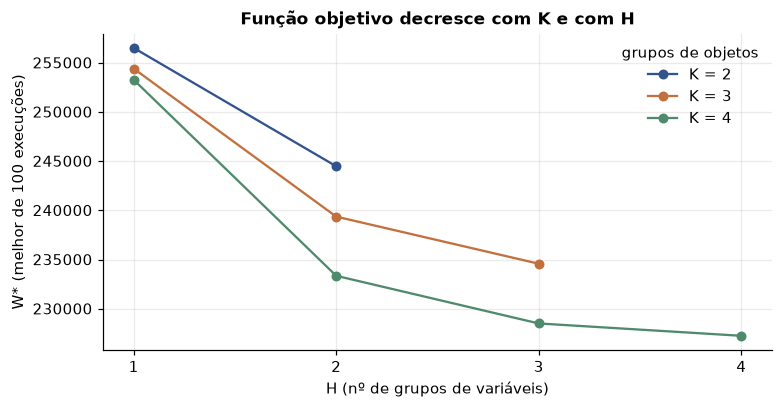

In [20]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
for K in K_VALUES:
    sub = tabela[tabela["K"] == K]
    ax.plot(sub["H"], sub["W_melhor"], marker="o", markersize=5.5,
            color=K_COLORS[K], label=f"K = {K}")
ax.set_xlabel("H (nº de grupos de variáveis)")
ax.set_ylabel("W* (melhor de 100 execuções)")
ax.set_xticks([1, 2, 3, 4])
ax.set_title("Função objetivo decresce com K e com H")
ax.legend(title="grupos de objetos")
plt.tight_layout()
plt.show()


## 4.2 Sensibilidade à solução inicial

O material de apoio adverte que *"os resultados finais obtidos são sensíveis à solução
inicial"*, é essa a razão de o enunciado exigir 100 execuções. O gráfico abaixo mostra a
dispersão de $W$ entre as 100 execuções de cada par, com o mínimo retido destacado.


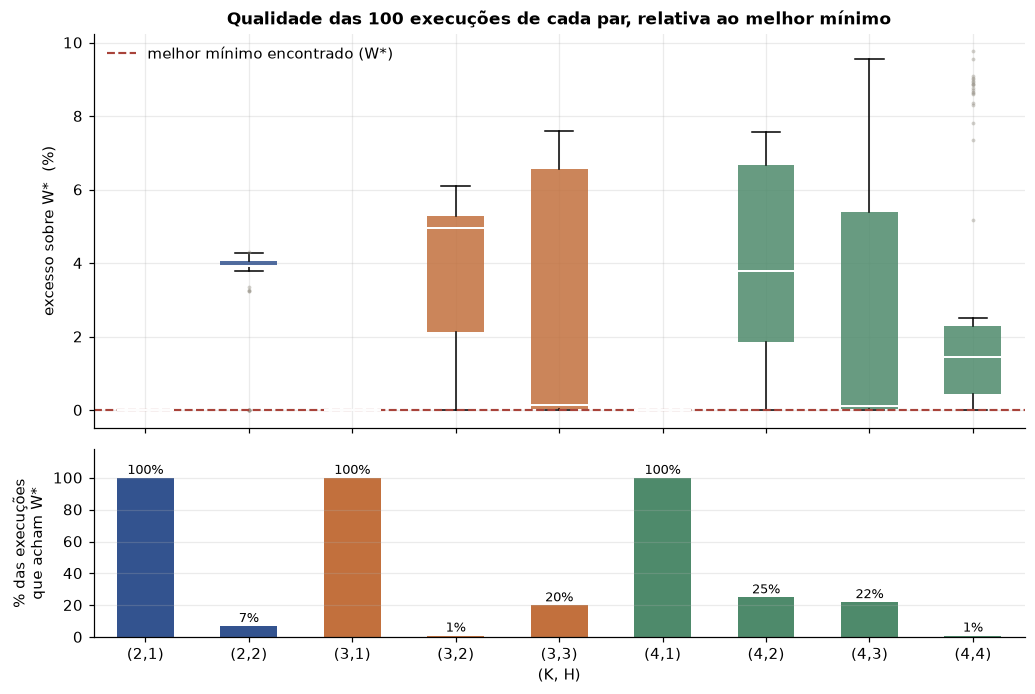

,K,H,W_melhor,W_medio,W_pior,pior_vs_melhor_%,execucoes_no_otimo_%
0,2,1,256513.75,256513.75,256513.75,0.00,100.0
1,2,2,244486.70,253508.20,255020.80,4.31,7.0
2,3,1,254414.01,254414.01,254414.01,0.00,100.0
3,3,2,239373.66,249021.53,253970.94,6.10,1.0
4,3,3,234585.87,241794.45,252441.95,7.61,20.0
5,4,1,253278.68,253278.68,253278.68,0.00,100.0
6,4,2,233358.70,242737.23,251038.48,7.58,25.0
7,4,3,228516.44,234976.14,250354.93,9.56,22.0
8,4,4,227261.65,233034.30,249452.04,9.76,1.0


In [21]:
rotulos = [f"({int(r.K)},{int(r.H)})" for r in tabela.itertuples()]

# Excesso relativo de cada execucao sobre o melhor W daquele par: 0% = encontrou o otimo.
# Normalizar assim coloca todos os pares em uma escala comum e comparavel.
excesso = [100 * (W_todas_execucoes[(int(r.K), int(r.H))] - r.W_melhor) / r.W_melhor
           for r in tabela.itertuples()]
TOL = 0.01   # tolerancia (%) para considerar que a execucao atingiu o melhor minimo
taxa_sucesso = [100 * np.mean(e <= TOL) for e in excesso]

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.4), sharex=True,
                         gridspec_kw={"height_ratios": [2.1, 1]})

# --- Painel 1: dispersao do excesso relativo
bp = axes[0].boxplot(excesso, patch_artist=True, widths=0.55,
                     medianprops={"color": "white", "linewidth": 1.3},
                     flierprops={"marker": "o", "markersize": 2.5, "alpha": 0.45,
                                 "markerfacecolor": C_MUTED, "markeredgecolor": "none"})
for caixa, r in zip(bp["boxes"], tabela.itertuples()):
    caixa.set_facecolor(K_COLORS[int(r.K)])
    caixa.set_alpha(0.85)
    caixa.set_edgecolor("none")
axes[0].axhline(0, color=C_ALERT, linewidth=1.4, linestyle="--",
                label="melhor mínimo encontrado (W*)")
axes[0].set_ylabel("excesso sobre W*  (%)")
axes[0].set_title("Qualidade das 100 execuções de cada par, relativa ao melhor mínimo")
axes[0].legend(loc="upper left")

# --- Painel 2: com que frequencia uma execucao encontra o melhor minimo
barras_taxa = axes[1].bar(range(1, len(rotulos) + 1), taxa_sucesso, width=0.55,
                          color=[K_COLORS[int(r.K)] for r in tabela.itertuples()])
for barra, taxa in zip(barras_taxa, taxa_sucesso):
    axes[1].text(barra.get_x() + barra.get_width() / 2, taxa + 2.5, f"{taxa:.0f}%",
                 ha="center", fontsize=8.5)
axes[1].set_ylim(0, 118)
axes[1].set_ylabel("% das execuções\nque acham W*")
axes[1].set_xlabel("(K, H)")
axes[1].set_xticks(range(1, len(rotulos) + 1))
axes[1].set_xticklabels(rotulos)
axes[1].grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

disp = tabela[["K", "H", "W_melhor", "W_medio", "W_pior"]].copy()
disp["pior_vs_melhor_%"] = (100 * (disp["W_pior"] - disp["W_melhor"]) / disp["W_melhor"])
disp["execucoes_no_otimo_%"] = taxa_sucesso
disp.round(2)


> **Leitura.** O painel inferior é o argumento quantitativo para as 100 execuções: com $H=1$ o
> problema é fácil e praticamente toda inicialização encontra o mesmo mínimo (caixa colapsada
> em 0% no painel superior), mas conforme $H$ e $K$ crescem a **taxa de sucesso despenca**, em
> vários pares, apenas uma pequena fração das execuções alcança o melhor mínimo, e a execução
> típica termina vários pontos percentuais acima dele.
>
> Isso confirma a advertência do material de apoio (*"os resultados finais obtidos são
> sensíveis à solução inicial"*): uma única execução teria alta probabilidade de entregar uma
> solução sensivelmente pior, e a estratégia de múltiplas inicializações é indispensável.


---
# 5. Escolha do número de clusters pela silhueta

Para cada par $(K,H)$, calcula-se a **silhueta média** da partição de objetos. Para o objeto
$i$, com $a(i)$ = dissimilaridade média aos objetos do próprio grupo e $b(i)$ =
dissimilaridade média mínima a um grupo alheio:

$$ s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}} \in [-1, 1] $$

Valores próximos de 1 indicam grupos compactos e bem separados. O critério do enunciado é

$$ K^* = \arg\max_{(K,H)} Sil(K,H). $$


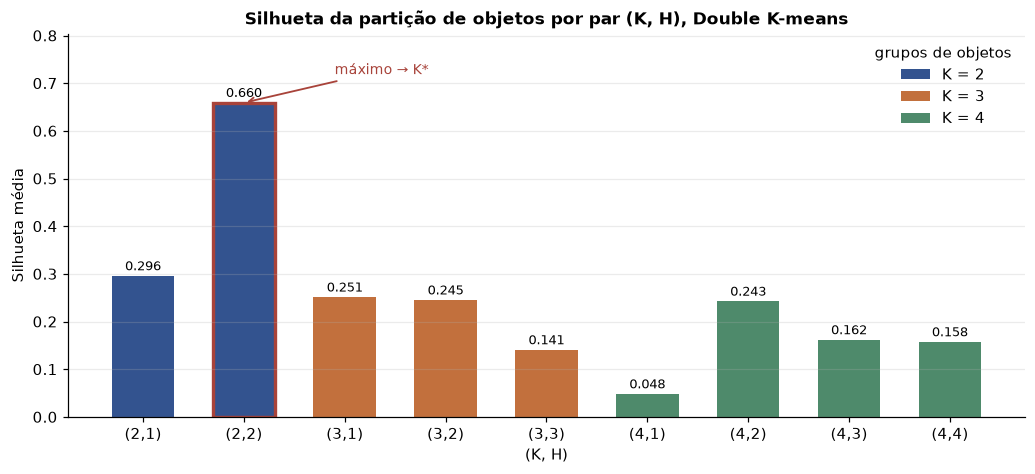

In [22]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
cores_barras = [K_COLORS[int(k)] for k in tabela["K"]]
barras = ax.bar(rotulos, tabela["Silhueta"], color=cores_barras, width=0.62)

idx_max = int(tabela["Silhueta"].idxmax())
barras[idx_max].set_edgecolor(C_ALERT)
barras[idx_max].set_linewidth(2.2)

for barra, valor in zip(barras, tabela["Silhueta"]):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 0.012, f"{valor:.3f}",
            ha="center", fontsize=8.5)

ax.annotate("máximo → K* ", xy=(idx_max, tabela["Silhueta"].iloc[idx_max]),
            xytext=(idx_max + 0.9, tabela["Silhueta"].iloc[idx_max] + 0.06),
            color=C_ALERT, fontsize=9,
            arrowprops={"arrowstyle": "->", "color": C_ALERT, "linewidth": 1.2})

ax.set_xlabel("(K, H)")
ax.set_ylabel("Silhueta média")
ax.set_ylim(0, tabela["Silhueta"].max() * 1.22)
ax.set_title("Silhueta da partição de objetos por par (K, H), Double K-means")
ax.legend(handles=[Patch(facecolor=K_COLORS[k], label=f"K = {k}") for k in K_VALUES],
          title="grupos de objetos", loc="upper right")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "silhueta_vs_KH.png", dpi=150, bbox_inches="tight")
plt.show()


In [23]:
linha_otima = tabela.loc[tabela["Silhueta"].idxmax()]
K_STAR, H_STAR = int(linha_otima["K"]), int(linha_otima["H"])
melhor_res = melhores[(K_STAR, H_STAR)]

print(f"(K*, H*) = ({K_STAR}, {H_STAR})")
print(f"  Silhueta = {linha_otima['Silhueta']:.4f}")
print(f"  W*       = {linha_otima['W_melhor']:,.2f}")
print(f"  convergiu em {melhor_res.n_iter} iteracoes")


(K*, H*) = (2, 2)
  Silhueta = 0.6596
  W*       = 244,486.70
  convergiu em 34 iteracoes


---
# 6. Índice de Rand corrigido

O **índice de Rand corrigido** (*Adjusted Rand Index*, ARI) compara duas partições dos mesmos
objetos, corrigindo pelo acordo esperado ao acaso:

$$ ARI = \frac{\sum_{ij}\binom{n_{ij}}{2} - \left[\sum_i\binom{a_i}{2}\sum_j\binom{b_j}{2}\right]/\binom{n}{2}}
{\frac{1}{2}\left[\sum_i\binom{a_i}{2}+\sum_j\binom{b_j}{2}\right] - \left[\sum_i\binom{a_i}{2}\sum_j\binom{b_j}{2}\right]/\binom{n}{2}} $$

$ARI = 1$ indica partições idênticas; $ARI \approx 0$ indica concordância equivalente ao acaso;
valores negativos indicam concordância **abaixo** do acaso.


In [24]:
ari_estrela = adjusted_rand_score(y, melhor_res.u)

print(f"ARI da particao com K* = {K_STAR} contra a particao a priori: {ari_estrela:+.4f}\n")

print("ARI de TODOS os pares (para contextualizar):")
comparacao = tabela[["K", "H", "Silhueta", "ARI"]].copy()
comparacao["selecionado"] = ["  <<< K*" if (int(r.K), int(r.H)) == (K_STAR, H_STAR) else ""
                             for r in comparacao.itertuples()]
comparacao.round(4)


ARI da particao com K* = 2 contra a particao a priori: -0.0049

ARI de TODOS os pares (para contextualizar):


,K,H,Silhueta,ARI,selecionado
0,2,1,0.2961,0.0686,
1,2,2,0.6596,-0.0049,<<< K*
2,3,1,0.2515,0.0784,
3,3,2,0.2454,0.1984,
4,3,3,0.1409,0.3854,
5,4,1,0.0484,0.0916,
6,4,2,0.2428,0.1493,
7,4,3,0.1620,0.2744,
8,4,4,0.1576,0.2451,


## 6.1 Uma referência externa: a silhueta do rótulo verdadeiro

O ARI nulo levanta uma pergunta que o enunciado não faz, mas que decide a interpretação de
tudo o que vem depois: **a partição *a priori* seria bem avaliada pela silhueta?**

A pergunta importa porque há duas explicações possíveis para o ARI $\approx 0$. Ou o algoritmo
falhou em encontrar uma estrutura que existe e é geometricamente boa, ou a estrutura
spam / não-spam simplesmente **não é compacta e separada** neste espaço, e nenhum critério
interno poderia tê-la selecionado. Basta calcular $Sil$ do próprio rótulo para distinguir.

In [25]:
# Silhueta da particao a priori, nos MESMOS dados padronizados usados no agrupamento
sil_apriori = silhouette_score(X, y)

referencia = pd.DataFrame({
    "Silhueta": [sil_apriori,
                 float(tabela["Silhueta"].min()),
                 float(linha_otima["Silhueta"])],
    "ARI": [1.0,
            float(tabela.loc[tabela["Silhueta"].idxmin(), "ARI"]),
            float(ari_estrela)],
}, index=["particao a priori (spam/nao-spam)",
          f"pior par do grid por silhueta ({int(tabela.loc[tabela['Silhueta'].idxmin(), 'K'])},"
          f"{int(tabela.loc[tabela['Silhueta'].idxmin(), 'H'])})",
          f"par selecionado (K*={K_STAR}, H*={H_STAR})"])

print(f"Silhueta da particao a priori : {sil_apriori:+.4f}")
print(f"Pares do grid com silhueta MENOR que a da particao a priori: "
      f"{int((tabela['Silhueta'] < sil_apriori).sum())} de {len(tabela)}")

referencia.round(4)

Silhueta da particao a priori : +0.0440
Pares do grid com silhueta MENOR que a da particao a priori: 0 de 9


,Silhueta,ARI
particao a priori (spam/nao-spam),0.0440,1.0000
"pior par do grid por silhueta (4,1)",0.0484,0.0916
"par selecionado (K*=2, H*=2)",0.6596,-0.0049


> **A resposta é decisiva.** A partição *a priori* tem silhueta $+0{,}044$, **menor que a dos
> nove pares** avaliados, inclusive menor que a do pior deles $(4,1)$, com $0{,}048$. Ou seja:
> mesmo que o Double K-means tivesse recuperado o rótulo spam / não-spam com perfeição, o
> critério $K^* = \arg\max Sil$ **teria descartado essa solução** em favor de qualquer outra
> do grid.
>
> Isso reposiciona o resultado das seções anteriores. O ARI nulo não é uma falha do algoritmo
> em encontrar o que existe: é o critério de seleção que, neste espaço, é estruturalmente cego
> à distinção spam / não-spam. O algoritmo encontrou exatamente o que lhe foi pedido, a
> partição geometricamente mais compacta e separada, e essa partição não é a semântica.

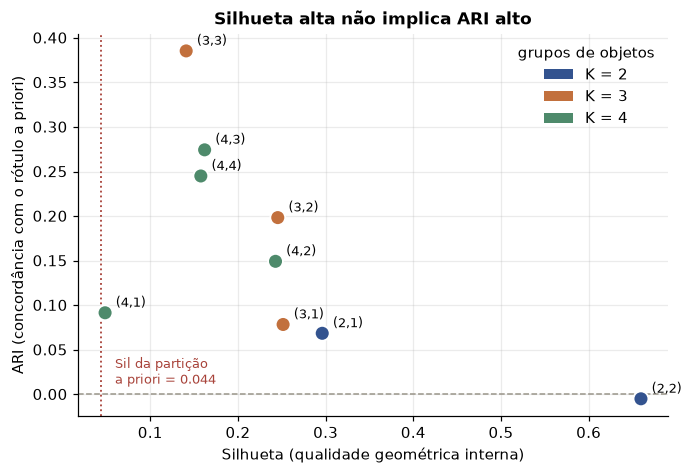

In [26]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.scatter(tabela["Silhueta"], tabela["ARI"], s=95,
           c=[K_COLORS[int(k)] for k in tabela["K"]], zorder=3, edgecolors="white",
           linewidths=1.2)
for r in tabela.itertuples():
    ax.annotate(f"({int(r.K)},{int(r.H)})", (r.Silhueta, r.ARI),
                textcoords="offset points", xytext=(7, 4), fontsize=8.5)
ax.axhline(0, color=C_MUTED, linewidth=1, linestyle="--")

# referencia: silhueta da propria particao a priori (Secao 6.1)
ax.axvline(sil_apriori, color=C_ALERT, linewidth=1.2, linestyle=":")
ax.annotate(f"Sil da partição\na priori = {sil_apriori:.3f}",
            xy=(sil_apriori, 0.0), textcoords="offset points",
            xytext=(9, 7), fontsize=8.5, color=C_ALERT)
ax.set_xlabel("Silhueta (qualidade geométrica interna)")
ax.set_ylabel("ARI (concordância com o rótulo a priori)")
ax.set_title("Silhueta alta não implica ARI alto")
ax.legend(handles=[Patch(facecolor=K_COLORS[k], label=f"K = {k}") for k in K_VALUES],
          title="grupos de objetos", loc="upper right")
plt.tight_layout()
plt.show()


> **Resultado central.** A solução selecionada pelo critério da silhueta tem
> **ARI praticamente nulo** ($-0{,}005$), a partição de objetos encontrada **não recupera** a
> distinção spam / não-spam.
>
> E há um agravante revelado pela tabela: entre os 9 pares, o de maior silhueta é exatamente
> o de **menor** ARI, o único negativo de todos. No extremo oposto, o par $(3,3)$, com uma das
> silhuetas mais baixas (0,14), alcança **ARI = 0,385**, de longe a melhor concordância com o
> rótulo. O gráfico acima torna essa relação inversa visível: nesta base, as duas medidas não
> apenas discordam, elas se **contradizem sistematicamente**.
>
> A linha pontilhada no gráfico marca a silhueta da partição *a priori* (Seção 6.1): **todos**
> os nove pares estão à direita dela, ou seja, todos são geometricamente "melhores" que o
> rótulo verdadeiro.
>
> Isso confirma a hipótese formulada ao final da análise exploratória (Seção 1.8) e exige
> explicação, é o que faz a Seção 8.


---
# 7. Resultados detalhados para $(K^*, H^*)$

Os três artefatos pedidos no enunciado, para o **melhor resultado segundo a função objetivo**
com $K^*$.


## 7.1 (i) Matriz de protótipos dos blocos $\mathbf{G}$

Cada entrada $g_{kh}$ é o valor médio do bloco formado pelo grupo de objetos $k$ e o grupo de
variáveis $h$, **em unidades padronizadas** (desvios-padrão em relação à média geral da
variável).


In [27]:
tam_obj = np.bincount(melhor_res.u, minlength=K_STAR)
tam_var = np.bincount(melhor_res.v, minlength=H_STAR)

G_df = pd.DataFrame(
    melhor_res.G,
    index=[f"objetos G{k} (n={tam_obj[k]})" for k in range(K_STAR)],
    columns=[f"variaveis G{h} (p={tam_var[h]})" for h in range(H_STAR)],
)
G_df.to_csv(RESULTS_DIR / "matriz_G_Kstar.csv")
G_df.round(4)


,variaveis G0 (p=46),variaveis G1 (p=11)
objetos G0 (n=4567),0.0011,-0.0511
objetos G1 (n=34),-0.1444,6.8612


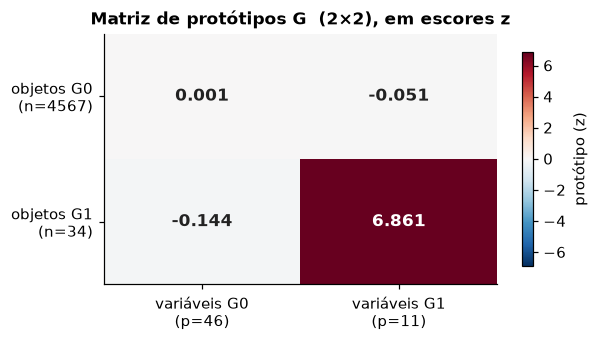

In [28]:
fig, ax = plt.subplots(figsize=(5.6, 3.2))
lim = np.abs(melhor_res.G).max()
im = ax.imshow(melhor_res.G, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")

for k in range(K_STAR):
    for h in range(H_STAR):
        valor = melhor_res.G[k, h]
        ax.text(h, k, f"{valor:.3f}", ha="center", va="center", fontsize=11,
                color="white" if abs(valor) > lim * 0.55 else "#222222",
                fontweight="600")

ax.set_xticks(range(H_STAR))
ax.set_xticklabels([f"variáveis G{h}\n(p={tam_var[h]})" for h in range(H_STAR)])
ax.set_yticks(range(K_STAR))
ax.set_yticklabels([f"objetos G{k}\n(n={tam_obj[k]})" for k in range(K_STAR)])
ax.set_title(f"Matriz de protótipos G  ({K_STAR}×{H_STAR}), em escores z")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85, label="protótipo (z)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "matriz_G_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [29]:
# Composicao dos grupos de variaveis
grupos_var = pd.Series(melhor_res.v, index=ATTRIBUTE_NAMES, name="grupo_variavel")
grupos_var.to_csv(RESULTS_DIR / "grupos_variaveis_Kstar.csv")

for h in range(H_STAR):
    membros = grupos_var[grupos_var == h].index.tolist()
    print(f"\nGrupo de variaveis G{h}  ({len(membros)} variaveis):")
    print("  " + ", ".join(membros))



Grupo de variaveis G0  (46 variaveis):
  word_freq_make, word_freq_address, word_freq_all, word_freq_3d, word_freq_our, word_freq_over, word_freq_remove, word_freq_internet, word_freq_order, word_freq_mail, word_freq_receive, word_freq_will, word_freq_people, word_freq_report, word_freq_addresses, word_freq_free, word_freq_business, word_freq_email, word_freq_you, word_freq_credit, word_freq_your, word_freq_font, word_freq_000, word_freq_money, word_freq_george, word_freq_data, word_freq_1999, word_freq_parts, word_freq_pm, word_freq_cs, word_freq_meeting, word_freq_original, word_freq_project, word_freq_re, word_freq_edu, word_freq_table, word_freq_conference, char_freq_;, char_freq_(, char_freq_[, char_freq_!, char_freq_$, char_freq_#, capital_run_length_average, capital_run_length_longest, capital_run_length_total

Grupo de variaveis G1  (11 variaveis):
  word_freq_hp, word_freq_hpl, word_freq_650, word_freq_lab, word_freq_labs, word_freq_telnet, word_freq_857, word_freq_415, word_

## 7.2 A matriz de dados reorganizada

O material de apoio abre apresentando o co-clustering como uma sequência de três matrizes:
**matriz inicial → matriz reorganizada → matriz de dimensão inferior (protótipos)**. Os dois
primeiros artefatos pedidos pelo enunciado correspondem ao terceiro elemento dessa sequência;
vale exibir a sequência completa, que é a leitura mais direta do que o algoritmo fez.

A figura abaixo reordena as **linhas** de $\mathbf{X}$ pelos clusters de objetos e as
**colunas** pelos grupos de variáveis, expondo os $K^* \times H^* = 4$ blocos. O painel (c)
retoma a matriz $\mathbf{G}$ da Seção 7.1, agora no contexto da tríade.

Como a base atinge 51 desvios-padrão, a escala de cor é recortada em $\pm 3$: sem o recorte,
toda a matriz apareceria uniformemente clara, com meia dúzia de pixels extremos.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


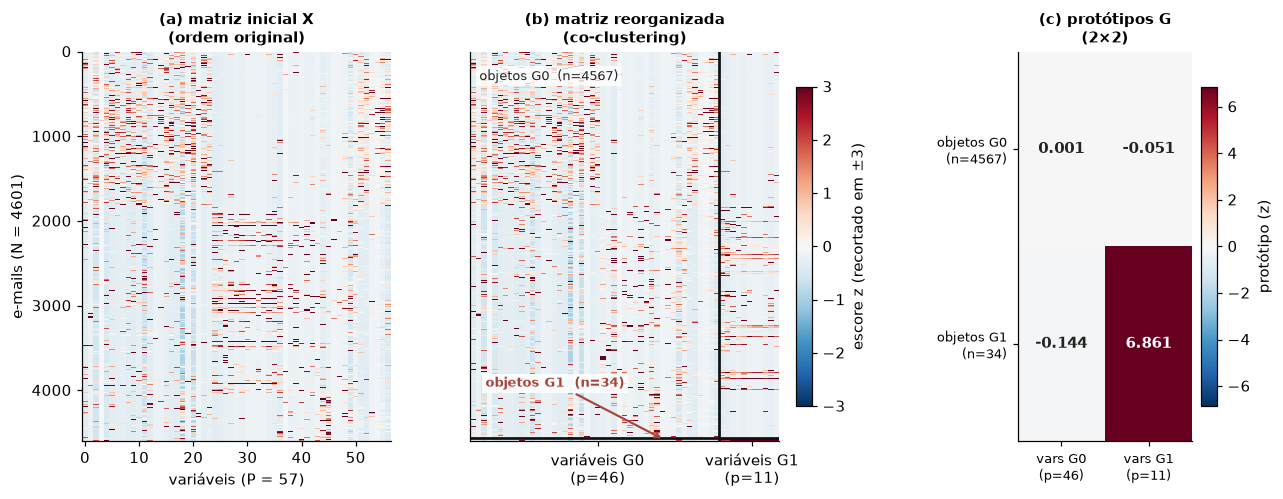

In [30]:
LIM_Z = 3.0   # recorte visual da escala de cor (a base chega a 51 sigmas)

ordem_obj = np.argsort(melhor_res.u, kind="stable")   # linhas agrupadas por cluster de objeto
ordem_var = np.argsort(melhor_res.v, kind="stable")   # colunas agrupadas por grupo de variavel
X_reorg = X[np.ix_(ordem_obj, ordem_var)]

corte_lin = np.cumsum(tam_obj)[:-1]                   # fronteiras entre blocos
corte_col = np.cumsum(tam_var)[:-1]
centro_lin = np.r_[0, np.cumsum(tam_obj)][:-1] + tam_obj / 2
centro_col = np.r_[0, np.cumsum(tam_var)][:-1] + tam_var / 2
k_min, k_max = int(np.argmin(tam_obj)), int(np.argmax(tam_obj))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6),
                         gridspec_kw={"width_ratios": [1, 1, 0.58], "wspace": 0.30})

# (a) matriz inicial, na ordem original de linhas e colunas
im = axes[0].imshow(np.clip(X, -LIM_Z, LIM_Z), cmap="RdBu_r", vmin=-LIM_Z, vmax=LIM_Z,
                    aspect="auto", interpolation="nearest")
axes[0].set_title("(a) matriz inicial X\n(ordem original)", fontsize=10)
axes[0].set_xlabel(f"variáveis (P = {P})")
axes[0].set_ylabel(f"e-mails (N = {N})")

# (b) mesma matriz, reordenada pelas duas particoes do Double K-means
axes[1].imshow(np.clip(X_reorg, -LIM_Z, LIM_Z), cmap="RdBu_r", vmin=-LIM_Z, vmax=LIM_Z,
               aspect="auto", interpolation="nearest")
for c in corte_lin:
    axes[1].axhline(c - 0.5, color="#111111", linewidth=1.8)
for c in corte_col:
    axes[1].axvline(c - 0.5, color="#111111", linewidth=1.8)
axes[1].set_title("(b) matriz reorganizada\n(co-clustering)", fontsize=10)
axes[1].set_xticks(centro_col)
axes[1].set_xticklabels([f"variáveis G{h}\n(p={tam_var[h]})" for h in range(H_STAR)])
axes[1].set_yticks([])
axes[1].text(P * 0.02, N * 0.045, f"objetos G{k_max}  (n={tam_obj[k_max]})", fontsize=8.5,
             va="top", color="#222222",
             bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none", "pad": 2})
axes[1].annotate(f"objetos G{k_min}  (n={tam_obj[k_min]})",
                 xy=(P * 0.62, corte_lin[0] + tam_obj[k_min] / 2),
                 xytext=(P * 0.04, N * 0.86), color=C_ALERT, fontsize=8.5, fontweight="600",
                 bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none", "pad": 2},
                 arrowprops={"arrowstyle": "->", "color": C_ALERT, "linewidth": 1.4})

# (c) a "lower dimensional matrix" do material de apoio: os K* x H* prototipos
lim_g = np.abs(melhor_res.G).max()
im_g = axes[2].imshow(melhor_res.G, cmap="RdBu_r", vmin=-lim_g, vmax=lim_g, aspect="auto")
for k in range(K_STAR):
    for h in range(H_STAR):
        valor = melhor_res.G[k, h]
        axes[2].text(h, k, f"{valor:.3f}", ha="center", va="center", fontsize=10,
                     color="white" if abs(valor) > lim_g * 0.55 else "#222222",
                     fontweight="600")
axes[2].set_title(f"(c) protótipos G\n({K_STAR}×{H_STAR})", fontsize=10)
axes[2].set_xticks(range(H_STAR))
axes[2].set_xticklabels([f"vars G{h}\n(p={tam_var[h]})" for h in range(H_STAR)],
                        fontsize=8.5)
axes[2].set_yticks(range(K_STAR))
axes[2].set_yticklabels([f"objetos G{k}\n(n={tam_obj[k]})" for k in range(K_STAR)], fontsize=8.5)

for eixo in axes:
    eixo.grid(False)
fig.colorbar(im, ax=axes[:2], shrink=0.82, pad=0.02,
             label=f"escore z (recortado em ±{LIM_Z:.0f})")
fig.colorbar(im_g, ax=axes[2], shrink=0.82, pad=0.04, label="protótipo (z)")
plt.savefig(RESULTS_DIR / "matriz_reorganizada.png", dpi=150, bbox_inches="tight")
plt.show()

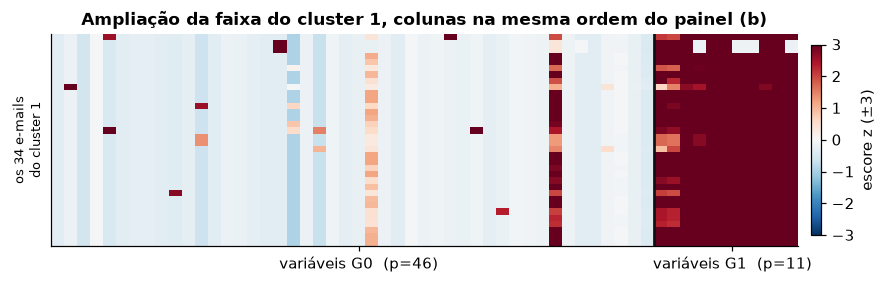

Media do bloco (objetos G1, variaveis G1): 6.861 desvios-padrao


In [31]:
# A faixa do cluster minoritario ocupa 34 das 4601 linhas do painel (b): ampliando-a.
bloco_menor = X[np.ix_(melhor_res.u == k_min, ordem_var)]

fig, ax = plt.subplots(figsize=(10.5, 2.5))
im = ax.imshow(np.clip(bloco_menor, -LIM_Z, LIM_Z), cmap="RdBu_r", vmin=-LIM_Z, vmax=LIM_Z,
               aspect="auto", interpolation="nearest")
for c in corte_col:
    ax.axvline(c - 0.5, color="#111111", linewidth=1.8)
ax.set_xticks(centro_col)
ax.set_xticklabels([f"variáveis G{h}  (p={tam_var[h]})" for h in range(H_STAR)])
ax.set_yticks([])
ax.set_ylabel(f"os {tam_obj[k_min]} e-mails\ndo cluster {k_min}", fontsize=8.5)
ax.set_title(f"Ampliação da faixa do cluster {k_min}, colunas na mesma ordem do painel (b)")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.9, pad=0.015, label=f"escore z (±{LIM_Z:.0f})")
plt.savefig(RESULTS_DIR / "matriz_reorganizada_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Media do bloco (objetos G{k_min}, variaveis G1): "
      f"{bloco_menor[:, tam_var[0]:].mean():.3f} desvios-padrao")

> **Leitura.** O painel (a) é ruído visual: nenhuma estrutura de bloco é perceptível na ordem
> original. O painel (b) mostra o que o co-clustering fez, e torna evidente por que a solução
> maximiza tanto $W$ quanto a silhueta: as colunas se dividem em um grupo grande e heterogêneo
> ($G_0$, 46 variáveis) e um grupo pequeno e quase sempre nulo ($G_1$, 11 variáveis), e as
> linhas se dividem em quase tudo ($G_0$) e uma **faixa fina de 34 e-mails** na base do painel.
> A ampliação confirma que esses 34 e-mails são vermelho saturado em **todas** as 11 variáveis
> de $G_1$ (média de 6,86 desvios), enquanto o restante da base é praticamente zero ali.
>
> O painel (c) resume tudo em quatro números: três próximos de zero e um igual a 6,86. Em
> outras palavras, das quatro entradas de $\mathbf{G}$, **uma só carrega informação**, e é a do
> bloco degenerado. É a leitura visual do mesmo diagnóstico que a Seção 8 desenvolve
> quantitativamente.
>
> A ampliação revela ainda um detalhe instrutivo: há uma coluna escura **dentro** de $G_0$,
> `char_freq_(` (média 2,8 desvios nesses 34 e-mails). Ela não foi para $G_1$ porque o Passo 3
> decide a partição das variáveis olhando os **4601** objetos, não os 34: no conjunto da base,
> essa variável se comporta como as demais de $G_0$.

## 7.3 (ii) Matriz de confusão: partição do algoritmo × partição *a priori*

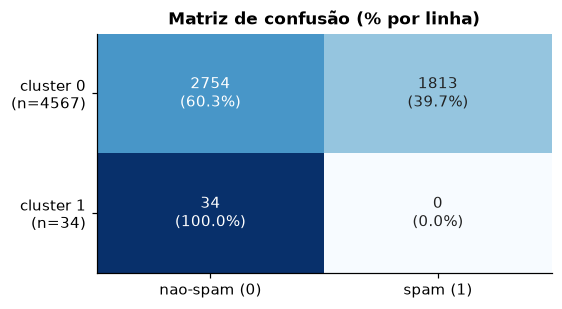

classe a priori,nao-spam (0),spam (1)
cluster (Double K-means),,
0,2754,1813
1,34,0


In [32]:
confusao = pd.crosstab(
    pd.Series(melhor_res.u, name="cluster (Double K-means)"),
    pd.Series(y, name="classe a priori").map({0: "nao-spam (0)", 1: "spam (1)"}),
)
confusao.to_csv(RESULTS_DIR / "matriz_confusao_Kstar.csv")

confusao_pct = confusao.div(confusao.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(5.2, 2.9))
im = ax.imshow(confusao_pct.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
for i in range(confusao.shape[0]):
    for j in range(confusao.shape[1]):
        n = confusao.iat[i, j]
        ax.text(j, i, f"{n}\n({confusao_pct.iat[i, j]:.1%})", ha="center", va="center",
                fontsize=10, color="white" if confusao_pct.iat[i, j] > 0.55 else "#222222")
ax.set_xticks(range(confusao.shape[1])); ax.set_xticklabels(confusao.columns)
ax.set_yticks(range(confusao.shape[0]))
ax.set_yticklabels([f"cluster {k}\n(n={tam_obj[k]})" for k in range(K_STAR)])
ax.set_title("Matriz de confusão (% por linha)")
ax.grid(False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "matriz_confusao_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

confusao


## 7.4 (iv) Função objetivo × iterações

Curva da melhor execução (a de menor $W$) do par $(K^*, H^*)$.


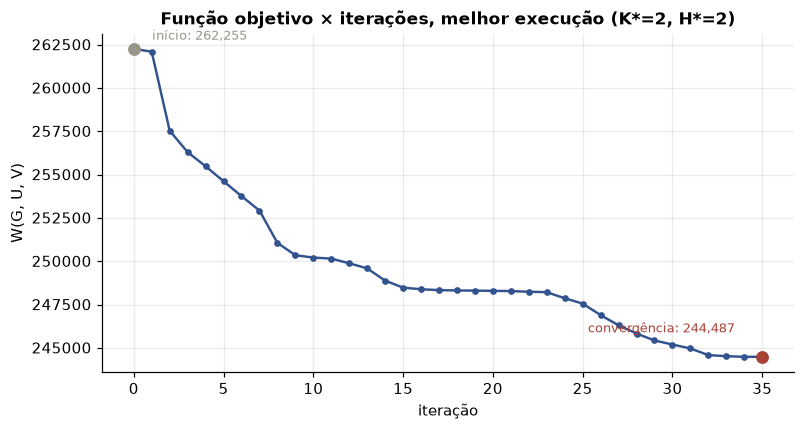

Reducao total de W: 6.78%   |   iteracoes ate a convergencia: 34
Monotonicamente nao crescente: True


In [33]:
historico = np.array(melhor_res.objective_history)

fig, ax = plt.subplots(figsize=(7.4, 4.0))
ax.plot(range(len(historico)), historico, marker="o", markersize=3.4,
        color=C_PRIMARY, linewidth=1.6)
ax.scatter([0], [historico[0]], s=55, color=C_MUTED, zorder=5)
ax.scatter([len(historico) - 1], [historico[-1]], s=55, color=C_ALERT, zorder=5)
ax.annotate(f"início: {historico[0]:,.0f}", (0, historico[0]),
            textcoords="offset points", xytext=(12, 6), fontsize=8.5, color=C_MUTED)
ax.annotate(f"convergência: {historico[-1]:,.0f}", (len(historico) - 1, historico[-1]),
            textcoords="offset points", xytext=(-18, 16), fontsize=8.5, color=C_ALERT,
            ha="right")
ax.set_xlabel("iteração")
ax.set_ylabel("W(G, U, V)")
ax.set_title(f"Função objetivo × iterações, melhor execução (K*={K_STAR}, H*={H_STAR})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "objetivo_vs_iteracoes_Kstar.png", dpi=150, bbox_inches="tight")
plt.show()

reducao = 100 * (historico[0] - historico[-1]) / historico[0]
print(f"Reducao total de W: {reducao:.2f}%   |   iteracoes ate a convergencia: {melhor_res.n_iter}")
print(f"Monotonicamente nao crescente: {bool(np.all(np.diff(historico) <= 1e-6))}")


## 7.5 Perfil de silhueta por objeto

Complemento útil: a silhueta média esconde a distribuição interna. O gráfico abaixo mostra
$s(i)$ de cada objeto, ordenado por grupo.


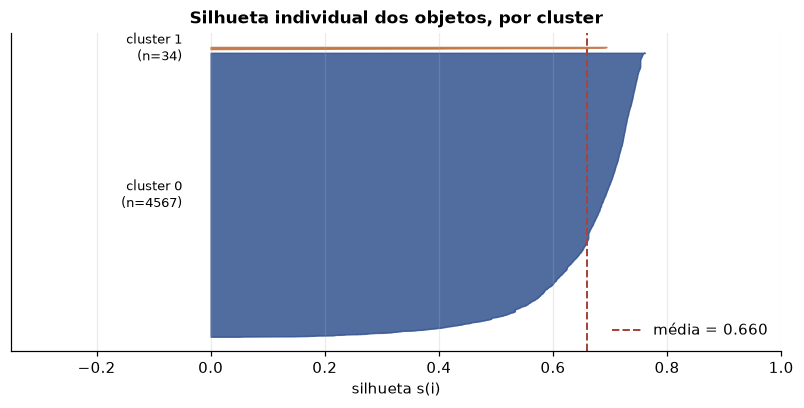

,n,silhueta_media,silhueta_minima
cluster 0,4567,0.6609,0.0493
cluster 1,34,0.4830,0.0023


In [34]:
sil_amostras = silhouette_samples(X, melhor_res.u)

fig, ax = plt.subplots(figsize=(7.4, 3.8))
y_base = 0
for k in range(K_STAR):
    valores = np.sort(sil_amostras[melhor_res.u == k])
    ax.fill_betweenx(np.arange(y_base, y_base + len(valores)), 0, valores,
                     color=[C_PRIMARY, C_SECONDARY, C_TERTIARY, C_MUTED][k % 4], alpha=0.85)
    ax.text(-0.05, y_base + len(valores) / 2, f"cluster {k}\n(n={len(valores)})",
            ha="right", va="center", fontsize=8.5)
    y_base += len(valores) + 60

ax.axvline(sil_amostras.mean(), color=C_ALERT, linestyle="--", linewidth=1.3,
           label=f"média = {sil_amostras.mean():.3f}")
ax.set_xlabel("silhueta s(i)")
ax.set_yticks([])
ax.set_xlim(-0.35, 1.0)
ax.set_title("Silhueta individual dos objetos, por cluster")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "n": [int((melhor_res.u == k).sum()) for k in range(K_STAR)],
    "silhueta_media": [sil_amostras[melhor_res.u == k].mean() for k in range(K_STAR)],
    "silhueta_minima": [sil_amostras[melhor_res.u == k].min() for k in range(K_STAR)],
}, index=[f"cluster {k}" for k in range(K_STAR)]).round(4)


---
# 8. Análise crítica dos resultados

Chegamos a um resultado aparentemente paradoxal: a partição **geometricamente melhor**
(silhueta 0,66, um valor alto para dados reais de alta dimensão) tem concordância **nula**
com o rótulo *a priori*. Esta seção investiga a causa.

## 8.1 Quem são os objetos do cluster minoritário?

O ponto de partida é caracterizar o grupo pequeno: em que variáveis ele difere do restante
da base?


In [35]:
cluster_menor = int(np.argmin(tam_obj))
cluster_maior = int(np.argmax(tam_obj))
mascara_menor = melhor_res.u == cluster_menor

print(f"Cluster minoritario: {cluster_menor}  (n = {tam_obj[cluster_menor]}, "
      f"{tam_obj[cluster_menor]/N:.2%} da base)")
print(f"Cluster majoritario: {cluster_maior}  (n = {tam_obj[cluster_maior]})")
print(f"Taxa de spam no cluster minoritario: {y[mascara_menor].mean():.1%}")
print(f"Taxa de spam no cluster majoritario: {y[~mascara_menor].mean():.1%}")
print(f"Taxa de spam na base inteira       : {y.mean():.1%}")


Cluster minoritario: 1  (n = 34, 0.74% da base)
Cluster majoritario: 0  (n = 4567)
Taxa de spam no cluster minoritario: 0.0%
Taxa de spam no cluster majoritario: 39.7%
Taxa de spam na base inteira       : 39.4%


In [36]:
# Variaveis que mais separam o cluster minoritario do restante (em escores z)
media_menor = X[mascara_menor].mean(axis=0)
media_resto = X[~mascara_menor].mean(axis=0)
separacao = pd.DataFrame({
    "grupo_variavel": melhor_res.v,
    "media_z_cluster_menor": media_menor,
    "media_z_demais": media_resto,
    "diferenca": media_menor - media_resto,
    "frac_zeros_na_base": (X_raw == 0).mean(axis=0),
}, index=ATTRIBUTE_NAMES).sort_values("diferenca", ascending=False)

separacao.head(14).round(3)


,grupo_variavel,media_z_cluster_menor,media_z_demais,diferenca,frac_zeros_na_base
word_freq_857,1,9.507,-0.071,9.578,0.955
word_freq_415,1,9.479,-0.071,9.550,0.953
word_freq_direct,1,8.742,-0.065,8.807,0.902
word_freq_telnet,1,8.104,-0.060,8.164,0.936
word_freq_technology,1,8.038,-0.060,8.098,0.870
word_freq_labs,1,7.204,-0.054,7.257,0.898
word_freq_85,1,6.066,-0.045,6.111,0.895
word_freq_650,1,5.958,-0.044,6.003,0.899
word_freq_lab,1,5.236,-0.039,5.275,0.919
word_freq_hp,1,3.679,-0.027,3.707,0.763


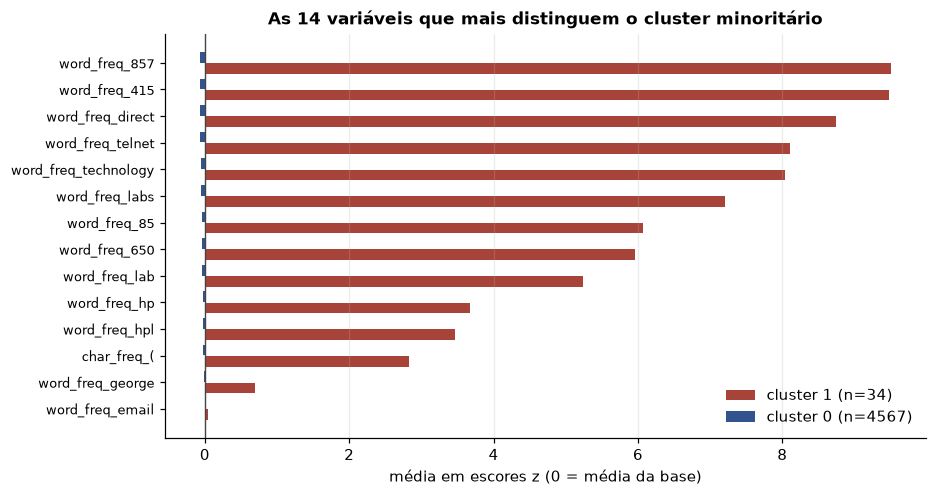

In [37]:
top = separacao.head(14).iloc[::-1]

fig, ax = plt.subplots(figsize=(8.6, 4.6))
posicoes = np.arange(len(top))
ax.barh(posicoes, top["media_z_cluster_menor"], height=0.4, color=C_ALERT,
        label=f"cluster {cluster_menor} (n={tam_obj[cluster_menor]})")
ax.barh(posicoes + 0.42, top["media_z_demais"], height=0.4, color=C_PRIMARY,
        label=f"cluster {cluster_maior} (n={tam_obj[cluster_maior]})")
ax.set_yticks(posicoes + 0.21)
ax.set_yticklabels(top.index, fontsize=8.5)
ax.axvline(0, color="#444", linewidth=0.9)
ax.set_xlabel("média em escores z (0 = média da base)")
ax.set_title("As 14 variáveis que mais distinguem o cluster minoritário")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()


## 8.2 O artefato do doador da base

O gráfico anterior é inequívoco: as **onze variáveis** com maior separação, todas com médias
entre 3,5 e 9,5 desvios-padrão acima da base, formam um único conjunto temático:

`word_freq_857`, `word_freq_415`, `word_freq_direct`, `word_freq_telnet`,
`word_freq_technology`, `word_freq_labs`, `word_freq_85`, `word_freq_650`,
`word_freq_lab`, `word_freq_hp`, `word_freq_hpl`, seguidas, um pouco abaixo, por
`word_freq_george`.

Essas não são palavras genéricas de "e-mail legítimo". São:

- **`857`, `415`, `650`**: códigos de área telefônicos da região do doador (Califórnia);
- **`hp`, `hpl`, `lab`, `labs`, `technology`, `telnet`**: o vocabulário do seu empregador (*HP Labs*);
- **`george`**: um nome próprio, presumivelmente do próprio doador.

Repare que essas mesmas variáveis já haviam aparecido, na análise exploratória (Seção 1.6),
como o único bloco fortemente correlacionado da base, inclusive o par `857`–`415`, com
correlação de 0,996.

Trata-se de um **artefato de coleta** bem conhecido do Spambase: os e-mails legítimos vieram
da caixa pessoal de uma única pessoa, e seu vocabulário idiossincrático ficou impresso nos
dados. Vejamos a evidência quantitativa.


In [38]:
vars_doador = ["word_freq_hp", "word_freq_hpl", "word_freq_george", "word_freq_650",
               "word_freq_lab", "word_freq_labs", "word_freq_telnet", "word_freq_857",
               "word_freq_415", "word_freq_85", "word_freq_technology", "word_freq_direct"]
vars_doador = [v for v in vars_doador if v in ATTRIBUTE_NAMES]

bruto = pd.DataFrame(X_raw, columns=ATTRIBUTE_NAMES)
evidencia = pd.DataFrame({
    "frac_zeros_na_base": (bruto[vars_doador] == 0).mean(),
    "media_bruta_cluster_menor": bruto.loc[mascara_menor, vars_doador].mean(),
    "media_bruta_demais": bruto.loc[~mascara_menor, vars_doador].mean(),
    "grupo_variavel_atribuido": grupos_var[vars_doador],
})
evidencia["razao"] = (evidencia["media_bruta_cluster_menor"]
                      / evidencia["media_bruta_demais"].replace(0, np.nan))
evidencia.round(3)


,frac_zeros_na_base,media_bruta_cluster_menor,media_bruta_demais,grupo_variavel_atribuido,razao
word_freq_hp,0.763,6.698,0.504,1,13.297
word_freq_hpl,0.824,3.334,0.243,1,13.744
word_freq_george,0.830,3.124,0.750,0,4.166
word_freq_650,0.899,3.334,0.101,1,33.019
word_freq_lab,0.919,3.205,0.076,1,42.292
word_freq_labs,0.898,3.392,0.078,1,43.291
word_freq_telnet,0.936,3.334,0.040,1,82.476
word_freq_857,0.955,3.170,0.024,1,133.224
word_freq_415,0.953,3.170,0.025,1,128.929
word_freq_85,0.895,3.334,0.081,1,40.963


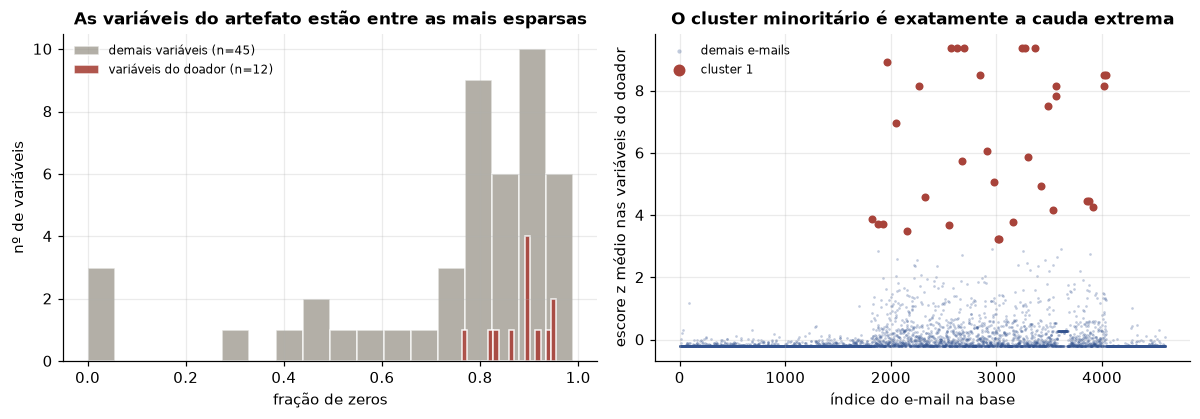

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))

# (a) esparsidade destas variaveis contra as demais
esparsidade_doador = (bruto[vars_doador] == 0).mean()
outras = [v for v in ATTRIBUTE_NAMES if v not in vars_doador]
esparsidade_outras = (bruto[outras] == 0).mean()

axes[0].hist(esparsidade_outras, bins=18, color=C_MUTED, alpha=0.75,
             label=f"demais variáveis (n={len(outras)})", edgecolor="white")
axes[0].hist(esparsidade_doador, bins=18, color=C_ALERT, alpha=0.9,
             label=f"variáveis do doador (n={len(vars_doador)})", edgecolor="white")
axes[0].set_xlabel("fração de zeros")
axes[0].set_ylabel("nº de variáveis")
axes[0].set_title("As variáveis do artefato estão entre as mais esparsas")
axes[0].legend(fontsize=8)

# (b) escore z medio destas variaveis, por objeto
escore_doador = X[:, [ATTRIBUTE_NAMES.index(v) for v in vars_doador]].mean(axis=1)
axes[1].scatter(np.arange(N)[~mascara_menor], escore_doador[~mascara_menor], s=3,
                alpha=0.3, color=C_PRIMARY, linewidths=0, label="demais e-mails")
axes[1].scatter(np.arange(N)[mascara_menor], escore_doador[mascara_menor], s=18,
                color=C_ALERT, label=f"cluster {cluster_menor}", zorder=4)
axes[1].set_xlabel("índice do e-mail na base")
axes[1].set_ylabel("escore z médio nas variáveis do doador")
axes[1].set_title("O cluster minoritário é exatamente a cauda extrema")
axes[1].legend(fontsize=8, markerscale=1.6)

plt.tight_layout()
plt.show()


## 8.3 O artefato não se restringe ao par selecionado

Até aqui o diagnóstico foi construído sobre o par $(K^*, H^*) = (2,2)$. Mas se a causa é o
vocabulário do doador combinado com a padronização, e não algo particular a esse par, então o
mesmo cluster de *outliers* deve reaparecer nas soluções dos **demais pares**. É uma previsão
testável do diagnóstico, e o grid de 9 pares já está calculado.

In [40]:
idx_doador = [ATTRIBUTE_NAMES.index(v) for v in vars_doador]

alcance = []
for K in K_VALUES:
    for H in range(1, K + 1):
        res_kh = melhores[(K, H)]
        tam_kh = np.bincount(res_kh.u, minlength=K)
        menor = int(np.argmin(tam_kh))
        na_franja = res_kh.u == menor
        ref = tabela[(tabela["K"] == K) & (tabela["H"] == H)].iloc[0]
        alcance.append({
            "K": K, "H": H,
            "menor_cluster_n": int(tam_kh[menor]),
            "menor_cluster_%": 100 * tam_kh[menor] / N,
            "spam_no_menor_%": 100 * y[na_franja].mean(),
            "z_medio_vars_doador": X[np.ix_(na_franja, idx_doador)].mean(),
            "Silhueta": ref["Silhueta"],
            "ARI": ref["ARI"],
        })

alcance = pd.DataFrame(alcance)
alcance.to_csv(RESULTS_DIR / "alcance_do_artefato.csv", index=False)

degenerados = alcance[alcance["menor_cluster_n"] < 100]
print(f"Pares cujo MENOR cluster tem menos de 100 objetos: {len(degenerados)} de {len(alcance)}")
print(f"  faixa de tamanhos: {degenerados['menor_cluster_n'].min()} a "
      f"{degenerados['menor_cluster_n'].max()} objetos")
print(f"  z medio nas variaveis do doador: {degenerados['z_medio_vars_doador'].min():.2f} a "
      f"{degenerados['z_medio_vars_doador'].max():.2f} desvios")
print(f"  taxa de spam: {degenerados['spam_no_menor_%'].min():.1f}% a "
      f"{degenerados['spam_no_menor_%'].max():.1f}%   (base inteira: {100*y.mean():.1f}%)")

alcance.round(3)

Pares cujo MENOR cluster tem menos de 100 objetos: 8 de 9
  faixa de tamanhos: 22 a 34 objetos
  z medio nas variaveis do doador: 5.81 a 7.44 desvios
  taxa de spam: 0.0% a 12.5%   (base inteira: 39.4%)


,K,H,menor_cluster_n,menor_cluster_%,spam_no_menor_%,z_medio_vars_doador,Silhueta,ARI
0,2,1,1018,22.126,58.350,0.359,0.296,0.069
1,2,2,34,0.739,0.000,6.348,0.660,-0.005
2,3,1,32,0.696,12.500,5.813,0.251,0.078
3,3,2,34,0.739,0.000,6.348,0.245,0.198
4,3,3,34,0.739,0.000,6.348,0.141,0.385
5,4,1,22,0.478,9.091,7.261,0.048,0.092
6,4,2,24,0.522,0.000,7.441,0.243,0.149
7,4,3,24,0.522,0.000,7.441,0.162,0.274
8,4,4,29,0.630,0.000,6.841,0.158,0.245


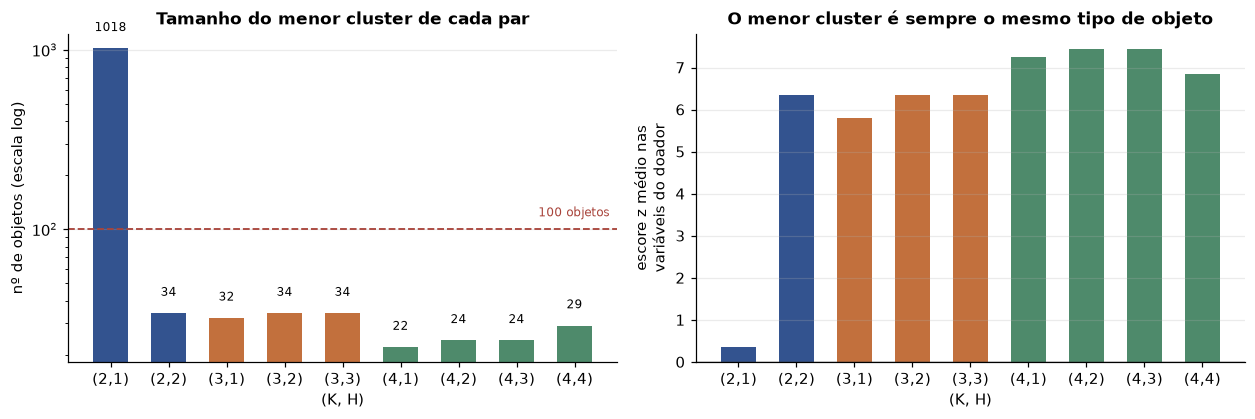

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), sharex=True)
x_pos = np.arange(len(rotulos))
cores_pares = [K_COLORS[int(k)] for k in alcance["K"]]

# (a) tamanho do menor cluster de cada par
axes[0].bar(x_pos, alcance["menor_cluster_n"], width=0.6, color=cores_pares)
axes[0].axhline(100, color=C_ALERT, linestyle="--", linewidth=1.2)
axes[0].text(len(rotulos) - 0.4, 118, "100 objetos", color=C_ALERT, fontsize=8, ha="right")
axes[0].set_yscale("log")
axes[0].set_ylabel("nº de objetos (escala log)")
axes[0].set_title("Tamanho do menor cluster de cada par")
for pos, valor in zip(x_pos, alcance["menor_cluster_n"]):
    axes[0].text(pos, valor * 1.25, str(int(valor)), ha="center", fontsize=8)

# (b) quao extremo e esse menor cluster nas variaveis do doador
axes[1].bar(x_pos, alcance["z_medio_vars_doador"], width=0.6, color=cores_pares)
axes[1].axhline(0, color="#444444", linewidth=0.9)
axes[1].set_ylabel("escore z médio nas\nvariáveis do doador")
axes[1].set_title("O menor cluster é sempre o mesmo tipo de objeto")

for eixo in axes:
    eixo.set_xticks(x_pos)
    eixo.set_xticklabels(rotulos)
    eixo.set_xlabel("(K, H)")
    eixo.grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "alcance_do_artefato.png", dpi=150, bbox_inches="tight")
plt.show()

> **A previsão se confirma, e com folga.** Em **oito dos nove pares** o menor cluster tem entre
> 22 e 34 objetos (menos de 0,8% da base) e é composto pelo mesmo tipo de e-mail: escores $z$
> médios de **5,8 a 7,4 desvios** nas variáveis do doador, contra 0 na base como um todo, e
> taxa de spam entre 0% e 12,5%, contra 39,4% na base. A única
> exceção é $(2,1)$, cujo menor cluster tem 1018 objetos, e não por acaso é o único par em que
> $H = 1$ impede o algoritmo de isolar o bloco de 11 variáveis em um grupo próprio.
>
> Duas consequências. Primeira: o artefato **não é uma peculiaridade do par selecionado**, ele
> contamina praticamente todo o grid, o que reforça que a causa está no pré-processamento dos
> dados e não em uma escolha infeliz de $(K,H)$. Segunda, e mais interessante: pares como
> $(3,3)$ carregam esse mesmo cluster degenerado **e ainda assim** alcançam ARI $= 0{,}385$.
> A explicação é que eles gastam um cluster com os *outliers* e usam os $K - 1$ restantes para
> dividir o corpo da base, e é essa divisão residual que captura parte da estrutura spam /
> não-spam. Com $K = 2$ não sobra cluster para isso: o único disponível além da franja precisa
> conter os 4567 e-mails restantes, spam e não-spam juntos.

> **Diagnóstico.** As variáveis do artefato estão entre as mais esparsas da base
> (`word_freq_george` é zero em 83% dos e-mails). Ao padronizar, os poucos e-mails em que elas
> ocorrem com frequência alta recebem escores $z$ da ordem de 6 a 8. O Double K-means, que
> minimiza soma de quadrados, **é sensível a valores discrepantes**, limitação listada
> explicitamente no material de apoio. O resultado é um cluster minúsculo, extremamente
> compacto e muito afastado do restante: exatamente a configuração que **maximiza a silhueta**.
>
> Em outras palavras: a silhueta de 0,66 é real, mas mede a separação de um punhado de
> *outliers*, não uma estrutura semântica de spam.

## 8.4 Onde está o cluster minoritário no espaço dos dados


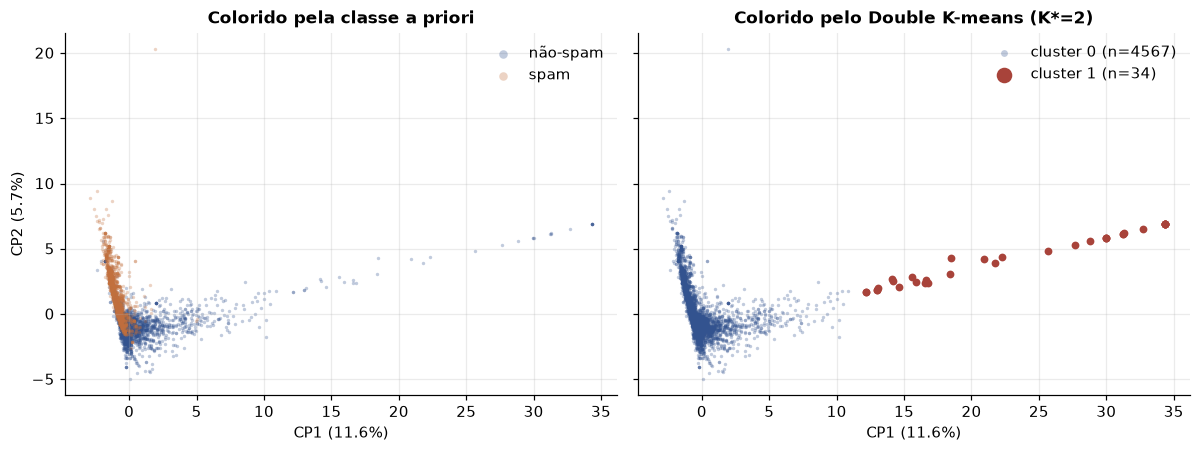

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)

for classe, cor, rot in [(0, C_PRIMARY, "não-spam"), (1, C_SECONDARY, "spam")]:
    m = y == classe
    axes[0].scatter(coords[m, 0], coords[m, 1], s=5, alpha=0.3, color=cor, label=rot,
                    linewidths=0)
axes[0].set_title("Colorido pela classe a priori")
axes[0].legend(markerscale=2.5, loc="upper right")

for k in range(K_STAR):
    m = melhor_res.u == k
    destaque = k == cluster_menor
    axes[1].scatter(coords[m, 0], coords[m, 1],
                    s=26 if destaque else 5,
                    alpha=1.0 if destaque else 0.3,
                    color=C_ALERT if destaque else C_PRIMARY,
                    label=f"cluster {k} (n={int(m.sum())})",
                    zorder=4 if destaque else 2, linewidths=0)
axes[1].set_title(f"Colorido pelo Double K-means (K*={K_STAR})")
axes[1].legend(markerscale=2.0, loc="upper right")

for eixo in axes:
    eixo.set_xlabel(f"CP1 ({ev[0]:.1%})")
axes[0].set_ylabel(f"CP2 ({ev[1]:.1%})")

plt.tight_layout()
plt.show()


> O contraste é eloquente: à esquerda, as classes se misturam por toda a nuvem; à direita, o
> algoritmo separa um braço isolado de pontos extremos. São estruturas geométricas
> completamente diferentes, e só a segunda é "compacta e bem separada", que é o que tanto a
> função objetivo quanto a silhueta recompensam.

## 8.5 Isso é uma limitação do Double K-means ou da base?

Um controle útil: aplicar um **k-means clássico** com $K=2$ aos mesmos dados padronizados.
Se ele também falhar em recuperar o rótulo, o problema está na base (e no pré-processamento),
não no co-clustering.


In [43]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=2, n_init=100, random_state=MASTER_SEED).fit(X)
sil_km = silhouette_score(X, km.labels_)
ari_km = adjusted_rand_score(y, km.labels_)

controle = pd.DataFrame({
    "Silhueta": [linha_otima["Silhueta"], sil_km],
    "ARI": [ari_estrela, ari_km],
    "menor_cluster": [int(tam_obj.min()), int(np.bincount(km.labels_).min())],
}, index=[f"Double K-means (K*={K_STAR}, H*={H_STAR})", "k-means clássico (K=2)"])

# As duas particoes sao a mesma? (ARI entre elas = 1 significa coincidencia exata)
concordancia = adjusted_rand_score(melhor_res.u, km.labels_)
print(f"ARI entre a particao do Double K-means e a do k-means classico: {concordancia:.4f}")
print(f"Numero de objetos atribuidos de forma diferente: "
      f"{int(min((melhor_res.u != km.labels_).sum(), (melhor_res.u == km.labels_).sum()))}")
controle.round(4)


ARI entre a particao do Double K-means e a do k-means classico: 1.0000
Numero de objetos atribuidos de forma diferente: 0


,Silhueta,ARI,menor_cluster
"Double K-means (K*=2, H*=2)",0.6596,-0.0049,34
k-means clássico (K=2),0.6596,-0.0049,34


> **Conclusão do controle: mais forte do que o esperado.** O k-means clássico não apenas
> falha do mesmo modo: ele converge para a **partição exatamente idêntica** (ARI entre as duas
> partições $= 1{,}000$; zero objetos classificados de forma diferente; os mesmos 34 e-mails
> isolados).
>
> Isso encerra a questão: **o resultado não é uma limitação do Double K-means**. Sob
> padronização z-score, a geometria euclidiana da base Spambase é de tal forma dominada pelos
> outliers do artefato do doador que *qualquer* método de partição por soma de quadrados com
> $K=2$ chega à mesma solução. A fronteira spam / não-spam simplesmente não corresponde a dois
> grupos compactos e separados nesse espaço, e a Seção 6.1 já havia quantificado isso por outro
> caminho: a silhueta do próprio rótulo verdadeiro, $0{,}044$, é menor que a de todos os nove
> pares do grid.

## 8.6 Estudo de sensibilidade: e se domarmos a assimetria?

Se o diagnóstico está correto, o resultado é dirigido por valores extremos criados pela
combinação (variável esparsa) × (padronização), então **atenuar a assimetria deve mudar o
resultado**. Testamos com a transformação $\log(1+x)$ antes da padronização, que comprime a
cauda direita sem alterar a ordem dos valores.

Repetimos **todo o protocolo** (9 pares × 100 execuções) sobre os dados transformados.


In [44]:
X_log = StandardScaler().fit_transform(np.log1p(X_raw))

print(f"Maior |z|, dados originais padronizados : {np.abs(X).max():.1f}")
print(f"Maior |z|, apos log(1+x) e padronizacao : {np.abs(X_log).max():.1f}")
print(f"Assimetria mediana, original : "
      f"{pd.DataFrame(X, columns=ATTRIBUTE_NAMES).skew().median():.2f}")
print(f"Assimetria mediana, log(1+x) : "
      f"{pd.DataFrame(X_log, columns=ATTRIBUTE_NAMES).skew().median():.2f}")


Maior |z|, dados originais padronizados : 51.0
Maior |z|, apos log(1+x) e padronizacao : 27.1
Assimetria mediana, original : 9.72
Assimetria mediana, log(1+x) : 4.40


In [45]:
registros_log = []
melhores_log = {}

t0 = time.time()
for K in K_VALUES:
    for H in range(1, K + 1):
        semente = MASTER_SEED * 2000 + K * 10 + H
        melhor_log, _ = run_many(X_log, K, H, n_init=N_INIT, seed=semente)
        sil = silhouette_score(X_log, melhor_log.u) if len(np.unique(melhor_log.u)) > 1 else np.nan
        registros_log.append({
            "K": K, "H": H,
            "W_melhor": melhor_log.objective,
            "Silhueta": sil,
            "ARI": adjusted_rand_score(y, melhor_log.u),
            "menor_cluster": int(np.bincount(melhor_log.u, minlength=K).min()),
        })
        melhores_log[(K, H)] = melhor_log

tabela_log = pd.DataFrame(registros_log)
print(f"Concluido em {time.time() - t0:.1f}s\n")
tabela_log.round(4)


Concluido em 72.7s



,K,H,W_melhor,Silhueta,ARI,menor_cluster
0,2,1,253042.5368,0.1895,0.1199,1203
1,2,2,244723.7158,0.0962,0.5359,1370
2,3,1,250484.3362,0.0252,0.0969,712
3,3,2,233541.3979,0.1249,0.4234,271
4,3,3,225299.1204,0.1187,0.4499,170
5,4,1,249369.2938,0.0017,0.0818,240
6,4,2,230188.2595,0.1223,0.2729,112
7,4,3,220016.2279,0.1204,0.4171,33
8,4,4,218925.3842,0.1218,0.4333,32


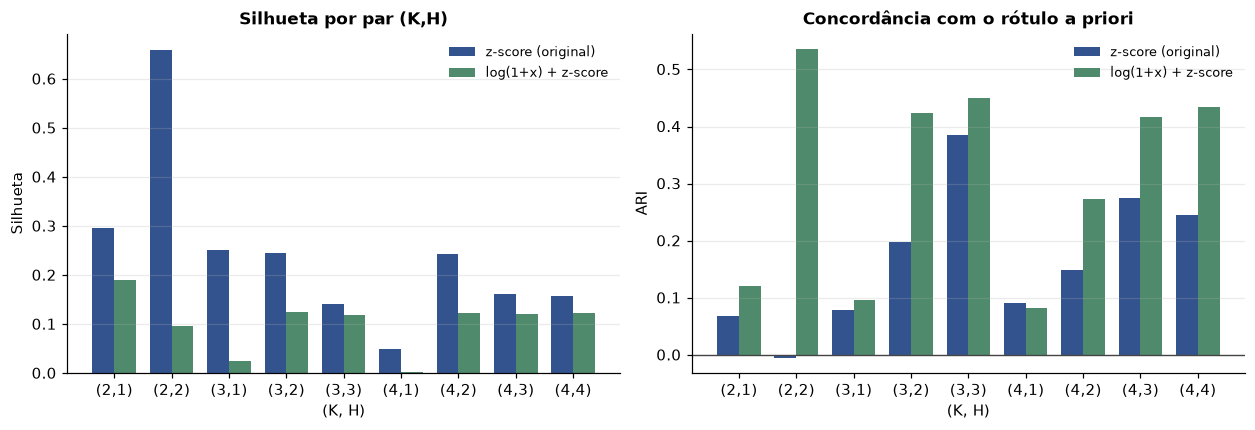

Variante log(1+x): (K*,H*) = (2, 1), Sil = 0.1895, ARI = +0.1199
Maior ARI alcancado na variante log(1+x): +0.5359 (par K=2, H=2)
Menor cluster nas solucoes log(1+x): 32 a 1370 objetos


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharex=True)
x_pos = np.arange(len(rotulos))
largura = 0.38

axes[0].bar(x_pos - largura/2, tabela["Silhueta"], largura, color=C_PRIMARY,
            label="z-score (original)")
axes[0].bar(x_pos + largura/2, tabela_log["Silhueta"], largura, color=C_TERTIARY,
            label="log(1+x) + z-score")
axes[0].set_ylabel("Silhueta")
axes[0].set_title("Silhueta por par (K,H)")

axes[1].bar(x_pos - largura/2, tabela["ARI"], largura, color=C_PRIMARY,
            label="z-score (original)")
axes[1].bar(x_pos + largura/2, tabela_log["ARI"], largura, color=C_TERTIARY,
            label="log(1+x) + z-score")
axes[1].axhline(0, color="#444", linewidth=0.9)
axes[1].set_ylabel("ARI")
axes[1].set_title("Concordância com o rótulo a priori")

for eixo in axes:
    eixo.set_xticks(x_pos)
    eixo.set_xticklabels(rotulos)
    eixo.set_xlabel("(K, H)")
    eixo.legend(fontsize=8.5)
    eixo.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

melhor_log_linha = tabela_log.loc[tabela_log["Silhueta"].idxmax()]
print(f"Variante log(1+x): (K*,H*) = ({int(melhor_log_linha['K'])}, "
      f"{int(melhor_log_linha['H'])}), Sil = {melhor_log_linha['Silhueta']:.4f}, "
      f"ARI = {melhor_log_linha['ARI']:+.4f}")
print(f"Maior ARI alcancado na variante log(1+x): {tabela_log['ARI'].max():+.4f} "
      f"(par K={int(tabela_log.loc[tabela_log['ARI'].idxmax(), 'K'])}, "
      f"H={int(tabela_log.loc[tabela_log['ARI'].idxmax(), 'H'])})")
print(f"Menor cluster nas solucoes log(1+x): "
      f"{tabela_log['menor_cluster'].min()} a {tabela_log['menor_cluster'].max()} objetos")


> **Resultado do estudo de sensibilidade: o diagnóstico se confirma.** A transformação
> $\log(1+x)$ reduz o maior escore $z$ de 51 para 27 e corta a assimetria mediana pela metade.
> Com isso:
>
> - **os clusters degenerados desaparecem**: para $K=2$, o menor grupo passa de 34 para
>   1203–1370 objetos, partições genuinamente equilibradas, em vez de um punhado de outliers;
> - **as silhuetas caem para a faixa normal** (0,00–0,19), o que é revelador: o valor de 0,66
>   do pipeline original **era o artefato**, não um sinal de estrutura forte;
> - **o ARI melhora de forma expressiva**: o par $(2,2)$ passa de $-0{,}005$ para
>   $\mathbf{+0{,}536}$, de "equivalente ao acaso" para concordância substancial com o rótulo,
>   com a mesma configuração $(K,H)$ e o mesmo algoritmo. A única coisa que mudou foi domar a
>   assimetria das variáveis esparsas.
>
> Note, porém, que o critério da silhueta **continua não sendo um bom guia**: sob $\log(1+x)$
> ele selecionaria $(2,1)$, com ARI 0,12, enquanto $(2,2)$ atinge 0,536. Índices internos
> medem compacidade geométrica, não relevância semântica.
>
> **Importante para a entrega:** os resultados oficiais reportados nas Seções 4 a 7 são os do
> pipeline padrão (z-score), conforme protocolo fixado *antes* de observar os resultados. Esta
> subseção é uma análise diagnóstica *a posteriori* e é reportada como tal, sem substituir o
> resultado oficial.


## 8.7 Ponte para a Questão 2

A Questão 2 pede duas versões do spambase: a primeira com a variável resposta original
(2 classes *a priori*) e a segunda "com a variável resposta com o número de classes igual ao
número de clusters de objetos ($K^*$)". Como $K^* = 2$, a segunda versão é a **partição de
objetos obtida aqui**, exportada em `results/particao_objetos_Kstar.csv`.

Convém registrar desde já uma consequência dessa partição, porque ela condiciona o desenho
experimental da Questão 2: a partição selecionada é **fortemente desbalanceada** (4567 × 34),
e isso não é um detalhe cosmético para os cinco classificadores pedidos.

In [47]:
rotulos_q2 = melhor_res.u     # variavel resposta da 2a versao do spambase (K* clusters)

def diagnostico_classes(rotulos, versao):
    tamanhos = np.bincount(rotulos)
    linhas = []
    for k, n in enumerate(tamanhos):
        # posto da estimativa de MV de Sigma_i: min(n - 1, P) quando ha posto cheio
        posto = int(np.linalg.matrix_rank(np.cov(X[rotulos == k], rowvar=False)))
        linhas.append({
            "versao": versao,
            "classe": k,
            "n": int(n),
            "proporcao": n / N,
            "n_no_treino_de_9_folds": int(np.floor(0.9 * n)),
            "n_no_fold_de_teste": int(np.floor(n / 10)),
            "posto_Sigma_estimada": posto,
            "Sigma_inversivel": posto == P,
        })
    return linhas

diag_q2 = pd.DataFrame(
    diagnostico_classes(y, "1a versao (rotulo original)")
    + diagnostico_classes(rotulos_q2, f"2a versao (K*={K_STAR} clusters)")
)
diag_q2.to_csv(RESULTS_DIR / "diagnostico_classes_questao2.csv", index=False)

print(f"P = {P} variaveis. A estimativa de maxima verossimilhanca de Sigma_i so eh")
print(f"inversivel (classificador bayesiano gaussiano) se a classe tiver n > {P} exemplos.\n")

alternativa = melhores_log[(K_STAR, H_STAR)]
print(f"Referencia: a variante log(1+x) do mesmo par ({K_STAR},{H_STAR}) daria classes de "
      f"tamanhos {np.bincount(alternativa.u).tolist()}, com ARI "
      f"{adjusted_rand_score(y, alternativa.u):+.4f} contra o rotulo a priori.")

diag_q2.round(4)

P = 57 variaveis. A estimativa de maxima verossimilhanca de Sigma_i so eh
inversivel (classificador bayesiano gaussiano) se a classe tiver n > 57 exemplos.

Referencia: a variante log(1+x) do mesmo par (2,2) daria classes de tamanhos [1370, 3231], com ARI +0.5359 contra o rotulo a priori.


,versao,classe,n,proporcao,n_no_treino_de_9_folds,n_no_fold_de_teste,posto_Sigma_estimada,Sigma_inversivel
0,1a versao (rotulo original),0,2788,0.6060,2509,278,57,True
1,1a versao (rotulo original),1,1813,0.3940,1631,181,57,True
2,2a versao (K*=2 clusters),0,4567,0.9926,4110,456,57,True
3,2a versao (K*=2 clusters),1,34,0.0074,30,3,16,False


> **Três consequências a antecipar na Questão 2.**
>
> 1. **Classificador bayesiano gaussiano.** A classe minoritária tem 34 exemplos em $P = 57$
>    dimensões; sua matriz de covariância estimada tem **posto 16** e é singular, de modo que
>    $\hat{\Sigma}_i^{-1}$ e $|\hat{\Sigma}_i|$ da regra de decisão não existem. Note que 16 é bem
>    menor que o limite $n - 1 = 33$: dentro desses 34 e-mails, dezenas de variáveis esparsas
>    são **constantes** (sempre zero), o que degrada ainda mais o posto. Nos 9 folds de
>    treinamento sobram ~30 exemplos, e a situação piora. Será preciso regularizar (*shrinkage*
>    na covariância, covariância comum às classes ou diagonal) ou reduzir a dimensionalidade,
>    e **documentar a escolha** como parte do ajuste de hiper-parâmetros.
> 2. **Validação cruzada $30 \times 10$-folds estratificada.** Com 34 exemplos, cada fold de
>    teste recebe ~3 deles. Precisão, cobertura e F-measure da classe minoritária passam a
>    assumir poucos valores discretos, e os intervalos de confiança pedidos no item (b) ficarão
>    largos. Vale reportar as métricas **por classe** e macro-médias, não apenas a taxa de erro
>    global, que uma regra trivial "tudo é classe 0" já deixaria em 0,7%.
> 3. **k-vizinhos, janela de Parzen e voto majoritário.** Com $P(\omega_1) \approx 0{,}0074$, a
>    classe minoritária dificilmente vence a comparação de $P(\omega_i \mid x_k)$, exceto
>    exatamente sobre os *outliers* que a definem. É um resultado esperado, não um erro, e deve
>    ser lido à luz do diagnóstico da Seção 8.2.
>
> Nada disso invalida o resultado da Questão 1: $K^* = 2$ é o que o critério do enunciado
> seleciona, e é o que segue para a Questão 2. A nota serve para que o desenho experimental da
> Questão 2 já nasça com essas decisões explicitadas, e para deixar registrado que existe uma
> alternativa defensável (a partição $\log(1+x)$, equilibrada e com ARI $= 0{,}536$) caso a
> orientação do curso seja usar uma variável resposta não degenerada.

---
# 9. Conclusões

**Sobre o protocolo.** Foram realizadas 900 execuções do Double K-means (9 pares $(K,H)$ ×
100 inicializações aleatórias). Delas, **899 convergiram** por ausência de transferências; uma
única execução do par $(4,2)$ atingiu o teto de 100 iterações sem convergir, e não é a execução
retida (a de menor $W$ desse par convergiu em 30 iterações). Todas as nove soluções retidas
convergiram, em 11 a 82 iterações. A análise de dispersão (Seção 4.2) mostrou que múltiplas
inicializações são de fato necessárias: os mínimos locais se multiplicam conforme $K$ e $H$
crescem.

**Sobre a escolha de $K^*$.** A função objetivo $W^*$ decresce monotonicamente com $K$ e $H$,
sendo portanto inadequada como critério de seleção. Pelo critério do enunciado
($K^* = \arg\max Sil$), a solução selecionada foi $(K^*, H^*) = (2, 2)$, com silhueta 0,66.

**Sobre o índice de Rand corrigido.** O ARI da partição selecionada é praticamente nulo
($-0{,}005$): a partição **não recupera** a distinção spam / não-spam. Pior: entre os 9 pares
avaliados, o escolhido pela silhueta é precisamente o de **menor** ARI, enquanto o par $(3,3)$,
com silhueta baixa, alcança ARI $= 0{,}385$. Investigamos a causa e a identificamos com
precisão:

1. o cluster minoritário (34 e-mails, 0,7% da base, **100% não-spam**) é definido por valores
   extremos (3,5 a 9,5 desvios) em variáveis ligadas ao **doador original dos dados**
   (`857`, `415`, `direct`, `telnet`, `technology`, `labs`, `85`, `650`, `lab`, `hp`, `hpl`),
   um artefato de coleta, não um sinal generalizável de "não-spam";
2. essas variáveis estão entre as mais **esparsas** da base (`george` é zero em 83% dos
   e-mails), e a padronização z-score converte seus raros valores não nulos em escores $z$
   extremos;
3. o Double K-means, por minimizar soma de quadrados, **é sensível a valores discrepantes**,
   limitação listada no material de apoio, e isolar esses pontos produz um cluster
   artificialmente compacto, que é exatamente o que a silhueta premia;
4. um **k-means clássico** de controle converge para a **partição idêntica** (ARI $=1$ entre as
   duas), provando que a limitação não é do co-clustering, mas da geometria da base sob esse
   pré-processamento;
5. o **estudo de sensibilidade** com $\log(1+x)$ fecha o argumento: atenuada a assimetria, os
   clusters deixam de ser degenerados (menor grupo passa de 34 para ~1300 objetos), as
   silhuetas caem para a faixa normal e o ARI do par $(2,2)$ sobe de $-0{,}005$ para
   $\mathbf{+0{,}536}$.

**Sobre o critério de seleção em si.** Dois resultados delimitam o que a silhueta podia e não
podia fazer nesta base. Primeiro, a silhueta da **própria partição a priori** é $0{,}044$
(Seção 6.1), menor que a dos nove pares avaliados: ainda que o algoritmo tivesse recuperado o
rótulo com perfeição, o critério $K^* = \arg\max Sil$ teria descartado essa solução. Segundo,
o cluster degenerado não é peculiaridade do par escolhido, ele aparece em **oito dos nove
pares**, com 22 a 34 objetos e o mesmo perfil extremo nas variáveis do doador (Seção 8.3); os
pares com $K \geq 3$ só alcançam ARI mais alto porque lhes sobram clusters para dividir o corpo
da base depois de gastar um com a franja de *outliers*.

**Lição metodológica.** Maximizar a silhueta seleciona a partição *geometricamente* melhor
separada, que não é necessariamente a mais *informativa* para o problema. Nesta base, índices
internos (silhueta) e externos (ARI) não apenas discordam: eles se ordenam de forma
aproximadamente inversa. Um valor alto de silhueta deve, portanto, ser sempre auditado,
pode estar medindo a compacidade de um grupo de outliers.

**Sobre o eixo das variáveis.** Apesar do resultado no eixo dos objetos, o co-clustering
entregou um agrupamento de variáveis **interpretável e coerente**: o grupo $G_1$ reúne
exatamente o bloco de termos mutuamente correlacionados identificado na análise exploratória
(Seção 1.6). O algoritmo capturou corretamente a estrutura de co-ocorrência, este é o valor
agregado do co-clustering em relação a agrupar apenas os objetos.

**Encaminhamento para a Questão 2.** O número de clusters a ser usado como variável resposta
alternativa é $K^* = 2$, e a partição correspondente está em
`results/particao_objetos_Kstar.csv`. Como essa partição é degenerada (4567 × 34), a Seção 8.7
registra as três consequências que o desenho experimental da Questão 2 precisa endereçar:
covariância singular no classificador bayesiano gaussiano, ~3 exemplos da classe minoritária
por fold de teste e métricas globais enganosas sob esse desbalanceamento.


---
## Exportação dos resultados

Consolidação dos artefatos numéricos em `results/`, para uso no relatório e na Questão 2.


In [48]:
tabela.to_csv(RESULTS_DIR / "tabela_KH.csv", index=False)
tabela_log.to_csv(RESULTS_DIR / "tabela_KH_sensibilidade_log.csv", index=False)
pd.DataFrame({"cluster_double_kmeans": melhor_res.u, "spam_a_priori": y}).to_csv(
    RESULTS_DIR / "particao_objetos_Kstar.csv", index=False)

resumo = {
    "K_star": K_STAR,
    "H_star": H_STAR,
    "silhueta_Kstar": float(linha_otima["Silhueta"]),
    "objetivo_Kstar": float(linha_otima["W_melhor"]),
    "ari_Kstar": float(ari_estrela),
    "n_iter_convergencia": int(melhor_res.n_iter),
    "convergiu": bool(melhor_res.converged),
    "n_execucoes_totais": int(len(registros) * N_INIT),
    "tamanho_clusters_objetos": {int(k): int(v) for k, v in enumerate(tam_obj)},
    "tamanho_grupos_variaveis": {int(h): int(v) for h, v in enumerate(tam_var)},
    "controle_kmeans_classico": {"silhueta": float(sil_km), "ari": float(ari_km)},
    "sensibilidade_log1p_ari_maximo": float(tabela_log["ARI"].max()),
}
with open(RESULTS_DIR / "resumo.json", "w", encoding="utf-8") as arquivo:
    json.dump(resumo, arquivo, indent=2, ensure_ascii=False)

print("Arquivos gravados em", RESULTS_DIR)
for caminho in sorted(RESULTS_DIR.iterdir()):
    print("  -", caminho.name)

print()
print(json.dumps(resumo, indent=2, ensure_ascii=False))


Arquivos gravados em /Users/yarafaran/Documents/AM/q1/results
  - alcance_do_artefato.csv
  - alcance_do_artefato.png
  - diagnostico_classes_questao2.csv
  - grupos_variaveis_Kstar.csv
  - matriz_G_Kstar.csv
  - matriz_G_heatmap.png
  - matriz_confusao_Kstar.csv
  - matriz_confusao_heatmap.png
  - matriz_reorganizada.png
  - matriz_reorganizada_zoom.png
  - objetivo_vs_iteracoes_Kstar.png
  - particao_objetos_Kstar.csv
  - resumo.json
  - silhueta_vs_KH.png
  - tabela_KH.csv
  - tabela_KH_sensibilidade_log.csv

{
  "K_star": 2,
  "H_star": 2,
  "silhueta_Kstar": 0.6596309439335903,
  "objetivo_Kstar": 244486.69834951469,
  "ari_Kstar": -0.00494969888751088,
  "n_iter_convergencia": 34,
  "convergiu": true,
  "n_execucoes_totais": 900,
  "tamanho_clusters_objetos": {
    "0": 4567,
    "1": 34
  },
  "tamanho_grupos_variaveis": {
    "0": 46,
    "1": 11
  },
  "controle_kmeans_classico": {
    "silhueta": 0.6596309439335903,
    "ari": -0.00494969888751088
  },
  "sensibilidade_log1p_